# Experimental Results — MAPF removal strategies

Reads the merged `raw_data.csv` (all maps) and renders, per map, the result tables
and plots that go into the PowerPoint. Run top to bottom. Paired significance tests
(McNemar for solved-rate, paired t-test for SST/Runtime) use `ALPHA` from the first cell.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, ttest_rel
%matplotlib inline

# Single merged file containing all maps (has a "Map" column)
RAW_DATA = r"C:\Users\user\Desktop\Research meetings\Meeting 16.6.26\raw_data.csv"
ALPHA = 0.05  # significance level used by every test in this notebook

STRATEGY_STYLE = {
    "DelayExclusion":  {"color": "steelblue", "marker": "o"},
    "RandomExclusion": {"color": "crimson",   "marker": "s"},
    "NoExclusion":     {"color": "green"},
    "AESTE":           {"color": "purple"},
}
FIXED_STRATEGIES = {"NoExclusion", "AESTE"}
TICKS_PCT   = np.arange(0, 1.001, 0.25)
TICK_LABELS = [f"{int(t*100)}%" for t in TICKS_PCT]

In [2]:
# ── Helpers ──────────────────────────────────────────────────────────────
def sig_mark(p):
    """Format a p-value with a two-tailed significance tick at ALPHA."""
    return "—" if pd.isna(p) else f"{p:.2e} {'✓' if p < ALPHA else '✗'}"


def plot_success_on_ax(ax, sub):
    line_strategies = [s for s in sub["How To Remove"].unique() if s not in FIXED_STRATEGIES]
    line_sub = sub[sub["How To Remove"].isin(line_strategies)]
    x_values = sorted(line_sub["Number of removed agents"].unique())

    if line_strategies and x_values:
        pivot = (line_sub.groupby(["How To Remove", "Number of removed agents"])["success"]
                 .sum().unstack("Number of removed agents", fill_value=0))
        for strategy in line_strategies:
            if strategy not in pivot.index:
                continue
            counts = [pivot.loc[strategy, n] if n in pivot.columns else 0 for n in x_values]
            style = STRATEGY_STYLE.get(strategy, {"color": "gray", "marker": "x"})
            ax.plot(x_values, counts, marker=style["marker"], label=strategy,
                    color=style["color"], linewidth=2)

    for strategy in FIXED_STRATEGIES:
        if strategy not in sub["How To Remove"].values:
            continue
        count = sub[sub["How To Remove"] == strategy]["success"].sum()
        ax.axhline(y=count, color=STRATEGY_STYLE.get(strategy, {"color": "gray"})["color"],
                   linestyle="--", linewidth=2, label=f"{strategy} ({count})")

    ax.set_xlabel("Number of Removed Agents", fontsize=11)
    ax.set_ylabel("Number of Successes", fontsize=11)
    if x_values:
        n_agents = int(sub["Number of agents"].iloc[0]) if not sub.empty else None
        n_minus_1 = n_agents - 1 if n_agents else None
        tick_labels = []
        for x in x_values:
            if x == 1:
                tick_labels.append(str(x))
            elif x == n_minus_1:
                tick_labels.append(f"{x}\n(N-1)")
            else:
                pct = int(round(x / n_agents * 100))
                tick_labels.append(f"{x}\n({pct}%)")
        ax.set_xticks(x_values)
        ax.set_xticklabels(tick_labels)
    ax.set_yticks(range(0, 501, 50))
    ax.set_ylim(0, 500)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)


def _nice_axis(global_max, n_ticks=5):
    """Return (y_max, yticks) with ~n_ticks intervals and 5% headroom above global_max."""
    padded = global_max * 1.05
    raw_step = padded / n_ticks
    magnitude = 10 ** math.floor(math.log10(raw_step))
    step = int(10 * magnitude)
    for factor in [1, 2, 3, 5, 10]:
        candidate = int(factor * magnitude)
        if candidate * n_ticks >= padded:
            step = candidate
            break
    y_max = int(math.ceil(padded / step)) * step
    return y_max, list(range(0, y_max + 1, step))


def grid_axes(dmap):
    """First 3 agent counts × first 3 goal counts, plus the per-cell subframes."""
    agent_vals = sorted(dmap["Number of agents"].unique())[:3]
    goal_vals  = sorted(dmap["Number of goals"].unique())[:3]
    subs = {
        (r, c): dmap[(dmap["Number of agents"] == a) & (dmap["Number of goals"] == g)]
        for r, a in enumerate(agent_vals)
        for c, g in enumerate(goal_vals)
    }
    return agent_vals, goal_vals, subs


def agg_context(dmap):
    """Per-map aggregate context: winner (Delay vs Random) + co-solved set across all 6 levels."""
    merge_keys = ["Instance", "Number of agents", "Number of goals"]
    wr_df = dmap[dmap["How To Remove"] == "NoExclusion"][merge_keys + ["Online SST", "Runtime"]]
    sm_df = dmap[dmap["How To Remove"] == "AESTE"][merge_keys + ["Online SST", "Runtime"]]

    de = dmap[dmap["How To Remove"] == "DelayExclusion"]["Online SST"].notna().sum()
    re = dmap[dmap["How To Remove"] == "RandomExclusion"]["Online SST"].notna().sum()
    winner = "DelayExclusion" if de >= re else "RandomExclusion"
    wdf = dmap[dmap["How To Remove"] == winner].copy()

    def _level(row):
        n, r = row["Number of agents"], row["Number of removed agents"]
        if r == 1: return "1"
        if r == n - 1: return "N-1"
        return f"{int(round(r / n * 100))}%"

    LEVEL_ORDER = ["1", "20%", "40%", "60%", "80%", "N-1"]
    wdf["removal_level"] = wdf.apply(_level, axis=1)
    winner_by_lvl = {lvl: wdf[wdf["removal_level"] == lvl] for lvl in LEVEL_ORDER}

    cos = sm_df[sm_df["Online SST"].notna()][merge_keys + ["Online SST", "Runtime"]].rename(
        columns={"Online SST": "SST_AESTE", "Runtime": "RT_AESTE"})
    for lvl in LEVEL_ORDER:
        lvl_rows = winner_by_lvl[lvl][merge_keys + ["Online SST", "Runtime"]].rename(
            columns={"Online SST": f"SST_{lvl}", "Runtime": f"RT_{lvl}"})
        if not lvl_rows.empty and not cos.empty:
            cos = cos.merge(lvl_rows, on=merge_keys)
            cos = cos[cos[f"SST_{lvl}"].notna()]

    aeste_total = len(sm_df)
    co_pct = len(cos) / aeste_total * 100 if aeste_total else 0
    return {
        "wr_df": wr_df, "sm_df": sm_df, "winner": winner,
        "win_color": STRATEGY_STYLE[winner]["color"],
        "winner_by_lvl": winner_by_lvl, "LEVEL_ORDER": LEVEL_ORDER,
        "cosolved": cos, "aeste_total": aeste_total, "co_pct": co_pct,
    }

In [3]:
# ── Load merged data, list maps, build per-map aggregate context ──────────
df_all = pd.read_csv(RAW_DATA)
df_all["success"] = df_all["Online SST"].notna()
maps = sorted(df_all["Map"].unique())

ctx_by_map = {m: agg_context(df_all[df_all["Map"] == m]) for m in maps}

## AESTE — Choose Remove Time

In [4]:
# AESTE Choose Remove Time at the largest (agents, goals) config per map
rows = []
for m in maps:
    d = df_all[(df_all["Map"] == m) & (df_all["How To Remove"] == "AESTE")]
    if d.empty:
        continue
    ma, mg = d["Number of agents"].max(), d["Number of goals"].max()
    t = d[(d["Number of agents"] == ma) & (d["Number of goals"] == mg)]["Choose Remove Time"].dropna()
    if t.empty:
        continue
    rows.append({"Map": m, "Num Agents": int(ma), "Num Goals": int(mg),
                 "Avg Choose Remove Time (s)": round(t.mean(), 3)})
choose_remove_time = pd.DataFrame(rows)
choose_remove_time

,Map,Num Agents,Num Goals,Avg Choose Remove Time (s)
0,den520d,150,300,12.677
1,ht_chantry,150,300,4.629
2,lak303d,150,300,7.384
3,maze-32-32-2,40,150,0.205
4,random-32-32-20,40,150,0.217
5,room-32-32-4,40,150,0.208


## AESTE vs NoExclusion — All Maps

In [5]:
# AESTE vs NoExclusion across all maps, with two-tailed significance tests (alpha=0.05)
#   Solved %        -> McNemar exact (paired binary), two-sided
#   Avg Online SST  -> paired t-test (ttest_rel), two-sided, on co-solved instances
#   Avg Runtime     -> paired t-test (ttest_rel), two-sided, on co-solved instances
keys = ["Instance", "Number of agents", "Number of goals"]

rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    ad = dm[dm["How To Remove"] == "AESTE"][keys + ["success", "Online SST", "Runtime"]]
    nd = dm[dm["How To Remove"] == "NoExclusion"][keys + ["success", "Online SST", "Runtime"]]
    mg = ad.merge(nd, on=keys, suffixes=("_a", "_n"))

    # Solved % (paired) + McNemar two-sided
    b = int((mg["success_a"] & ~mg["success_n"]).sum())   # AESTE solved, NoExclusion not
    c = int((~mg["success_a"] & mg["success_n"]).sum())   # NoExclusion solved, AESTE not
    p_solved = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0

    # Co-solved set (both solved) + paired t-tests two-sided
    co = mg[mg["success_a"] & mg["success_n"]]
    co_pct = len(co) / len(mg) * 100 if len(mg) else 0
    p_sst = ttest_rel(co["Online SST_a"], co["Online SST_n"]).pvalue if len(co) > 1 else float("nan")
    p_rt  = ttest_rel(co["Runtime_a"],   co["Runtime_n"]).pvalue   if len(co) > 1 else float("nan")

    stats = {
        "AESTE":       (mg["success_a"].mean() * 100, co["Runtime_a"].mean(), co["Online SST_a"].mean()),
        "NoExclusion": (mg["success_n"].mean() * 100, co["Runtime_n"].mean(), co["Online SST_n"].mean()),
    }
    for s, (solved, rt, sst) in stats.items():
        rows.append({
            "Map": m, "Strategy": s,
            "Solved %": f"{solved:.2f}%",
            "Co-solved %": f"{co_pct:.2f}%",
            "Avg Runtime": round(rt, 2),
            "Avg Online SST": round(sst, 2),
            "Solved p (McNemar)":  sig_mark(p_solved) if s == "AESTE" else "",
            "SST p (t-test)":      sig_mark(p_sst)    if s == "AESTE" else "",
            "Runtime p (t-test)":  sig_mark(p_rt)     if s == "AESTE" else "",
        })
aeste_vs_noexclusion = pd.DataFrame(rows)
aeste_vs_noexclusion

,Map,Strategy,Solved %,Co-solved %,Avg Runtime,Avg Online SST,Solved p (McNemar),SST p (t-test),Runtime p (t-test)
0,den520d,AESTE,92.58%,81.87%,86.89,15451.99,3.02e-21 ✓,0.00e+00 ✓,2.84e-14 ✓
1,den520d,NoExclusion,87.00%,81.87%,96.73,17430.33,,,
2,ht_chantry,AESTE,77.20%,54.00%,105.22,7790.67,1.76e-45 ✓,3.18e-249 ✓,4.32e-22 ✓
3,ht_chantry,NoExclusion,64.98%,54.00%,123.07,8650.39,,,
4,lak303d,AESTE,81.53%,62.44%,96.91,11767.75,3.25e-26 ✓,4.54e-303 ✓,1.68e-37 ✓
5,lak303d,NoExclusion,72.98%,62.44%,118.23,13109.39,,,
6,maze-32-32-2,AESTE,67.89%,51.16%,61.80,3006.94,3.28e-22 ✓,5.44e-40 ✓,2.05e-10 ✓
7,maze-32-32-2,NoExclusion,60.53%,51.16%,72.24,3171.30,,,
8,random-32-32-20,AESTE,83.16%,70.22%,57.42,2669.34,1.05e-15 ✓,5.30e-57 ✓,5.09e-19 ✓
9,random-32-32-20,NoExclusion,77.76%,70.22%,69.62,2814.35,,,


## AESTE vs NoExclusion — solved-rate gain per configuration (all maps)

In [6]:
# Per-config solved-rate gain (AESTE% − NoExclusion%) + McNemar paired test
# Sign: +N% = AESTE solved N percentage points more, -N% = NoExclusion solved more
# McNemar (exact binomial on discordant pairs): b = AESTE-only solved, c = NoExclusion-only solved
rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    for a in sorted(dm["Number of agents"].unique()):
        for g in sorted(dm["Number of goals"].unique()):
            mask = (dm["Number of agents"] == a) & (dm["Number of goals"] == g)
            a_df = dm[mask & (dm["How To Remove"] == "AESTE")][["Instance", "success"]]
            n_df = dm[mask & (dm["How To Remove"] == "NoExclusion")][["Instance", "success"]]
            if a_df.empty or n_df.empty:
                continue
            merged = a_df.merge(n_df, on="Instance", suffixes=("_a", "_n"))
            gain = (merged["success_a"].mean() - merged["success_n"].mean()) * 100
            b = (merged["success_a"] & ~merged["success_n"]).sum()   # AESTE solved, NoExclusion not
            c = (~merged["success_a"] & merged["success_n"]).sum()   # NoExclusion solved, AESTE not
            pval = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0
            rows.append({"Map": m, "Agents": a, "Goals": g,
                         "Gain": f"{gain:+.1f}%",
                         "McNemar p": f"{pval:.4f}",
                         "Significant": "Yes" if pval < ALPHA else "No"})
config_gain = pd.DataFrame(rows)
config_gain

,Map,Agents,Goals,Gain,McNemar p,Significant
0,den520d,100,200,+4.8%,0.0005,Yes
1,den520d,100,250,+5.6%,0.0013,Yes
2,den520d,100,300,+6.0%,0.0042,Yes
3,den520d,120,200,+4.2%,0.0046,Yes
4,den520d,120,250,+8.2%,0.0000,Yes
5,den520d,120,300,+4.8%,0.0264,Yes
6,den520d,150,200,+3.8%,0.0066,Yes
7,den520d,150,250,+4.2%,0.0275,Yes
8,den520d,150,300,+8.6%,0.0001,Yes
9,ht_chantry,100,200,+10.4%,0.0000,Yes


## AESTE vs NoExclusion — SST cactus (all maps)

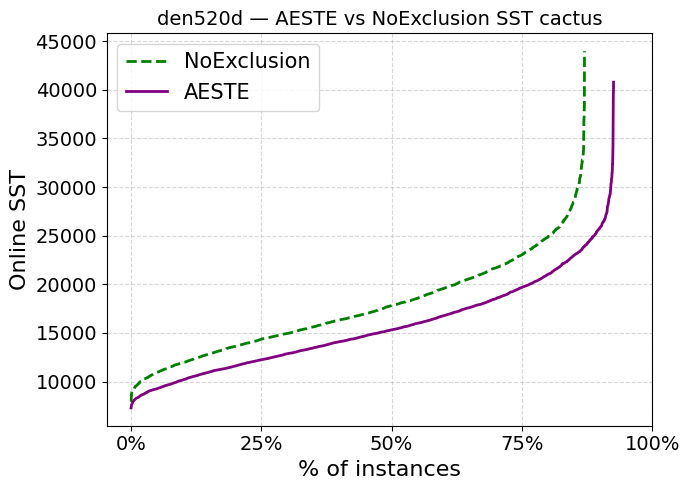

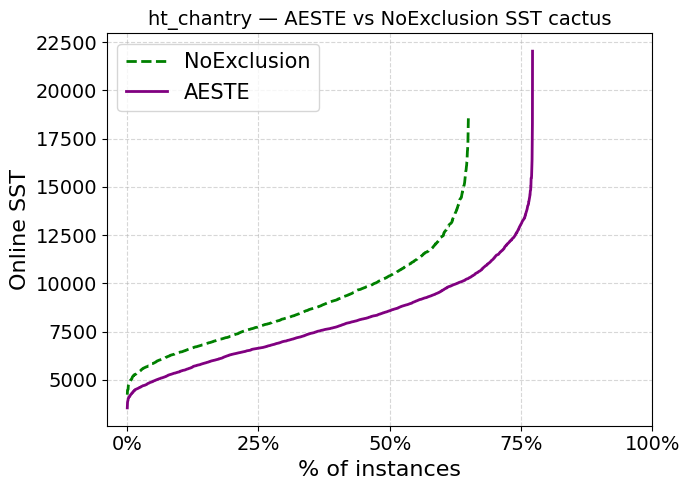

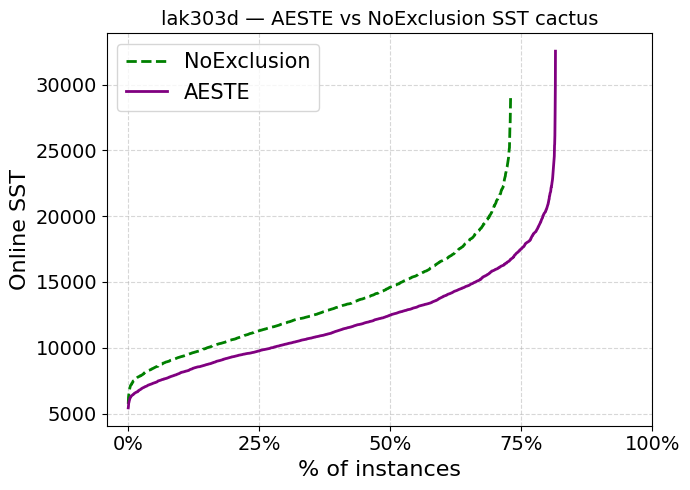

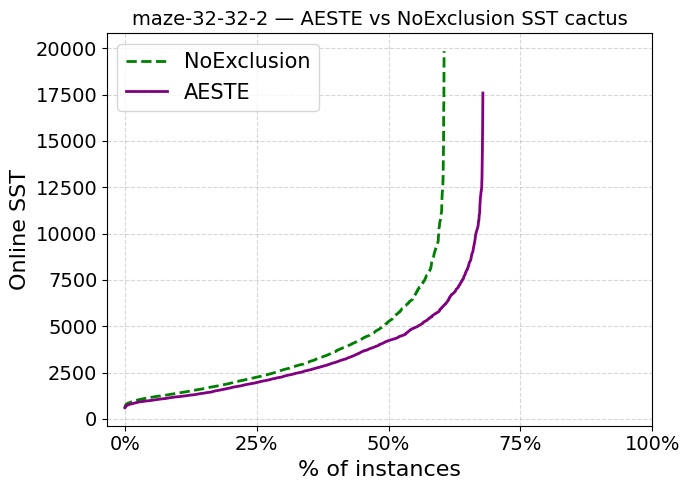

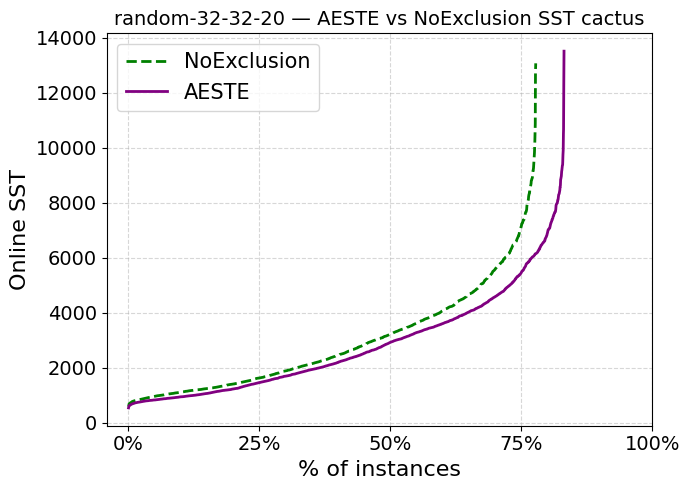

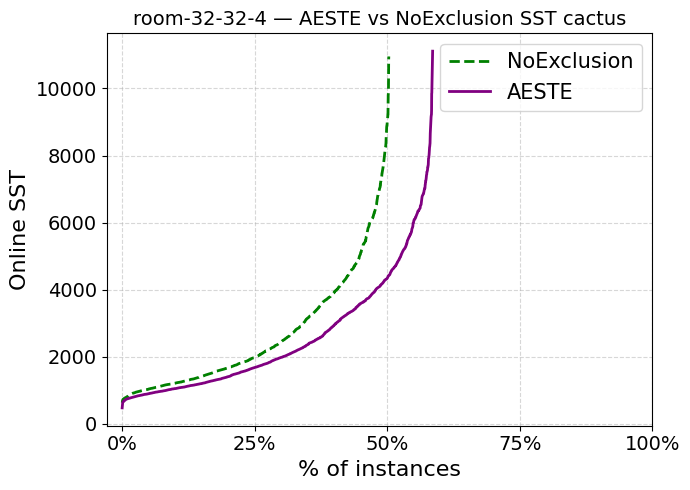

In [7]:
def plot_sst_cactus(ctx, map_name):
    fig, ax = plt.subplots(figsize=(7, 5))
    for strategy, src, ls in (("NoExclusion", ctx["wr_df"], "--"), ("AESTE", ctx["sm_df"], "-")):
        vals = src["Online SST"].dropna().sort_values().values
        n_total = len(src)
        if len(vals) == 0 or n_total == 0:
            continue
        ax.plot(np.arange(1, len(vals) + 1) / n_total, vals,
                label=strategy, color=STRATEGY_STYLE[strategy]["color"], linewidth=2, linestyle=ls)
    ax.set_xlabel("% of instances", fontsize=16)
    ax.set_ylabel("Online SST", fontsize=16)
    ax.set_xticks(TICKS_PCT)
    ax.set_xticklabels(TICK_LABELS, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.legend(fontsize=15)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(f"{map_name} — AESTE vs NoExclusion SST cactus", fontsize=14)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_sst_cactus(ctx_by_map[m], m)

## AESTE successes by % of agents removed (3×3 grid, all maps)

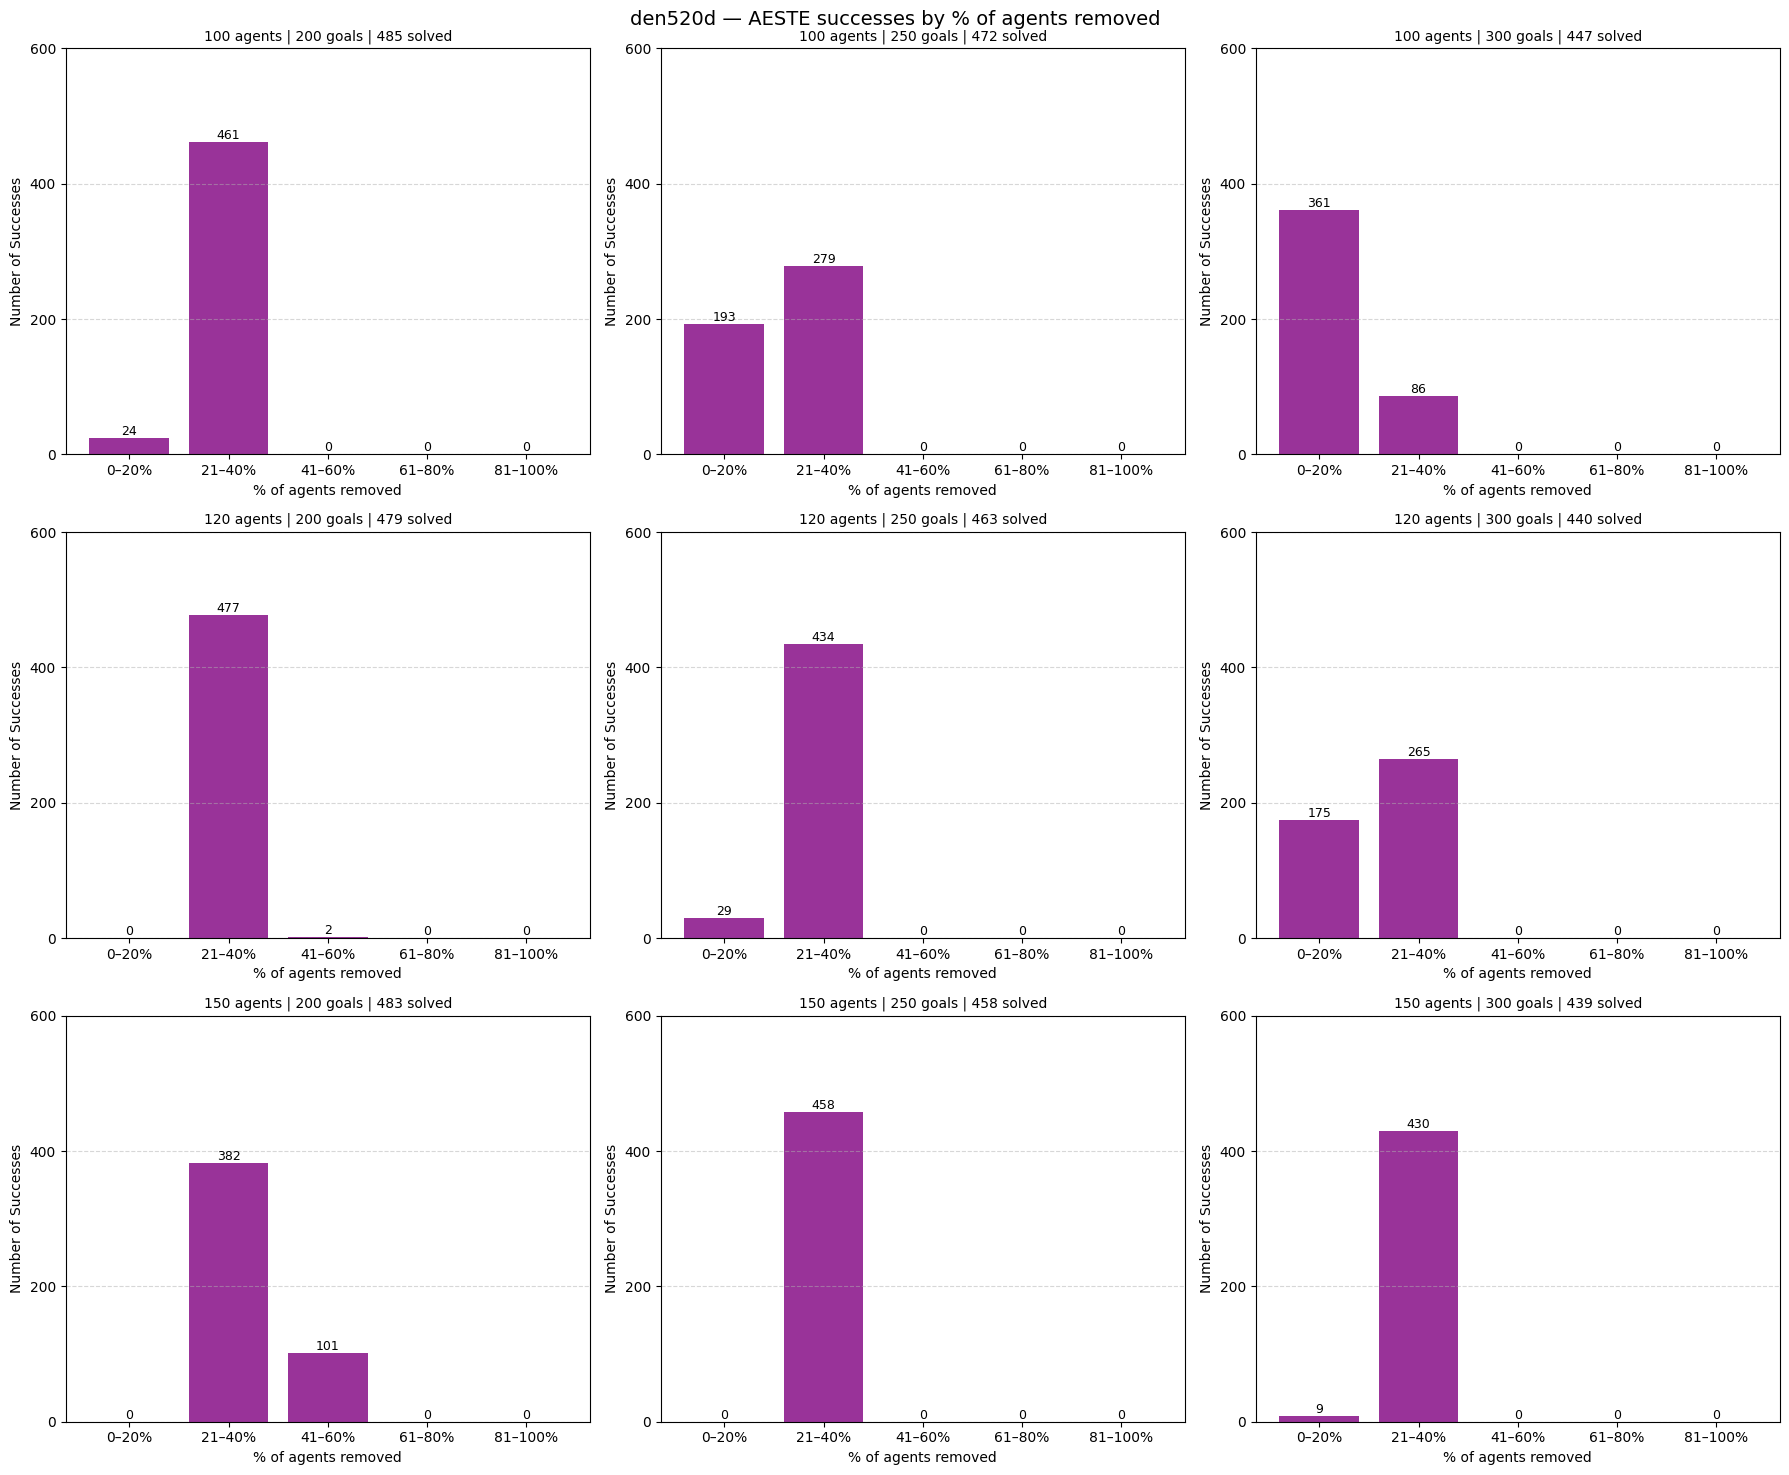

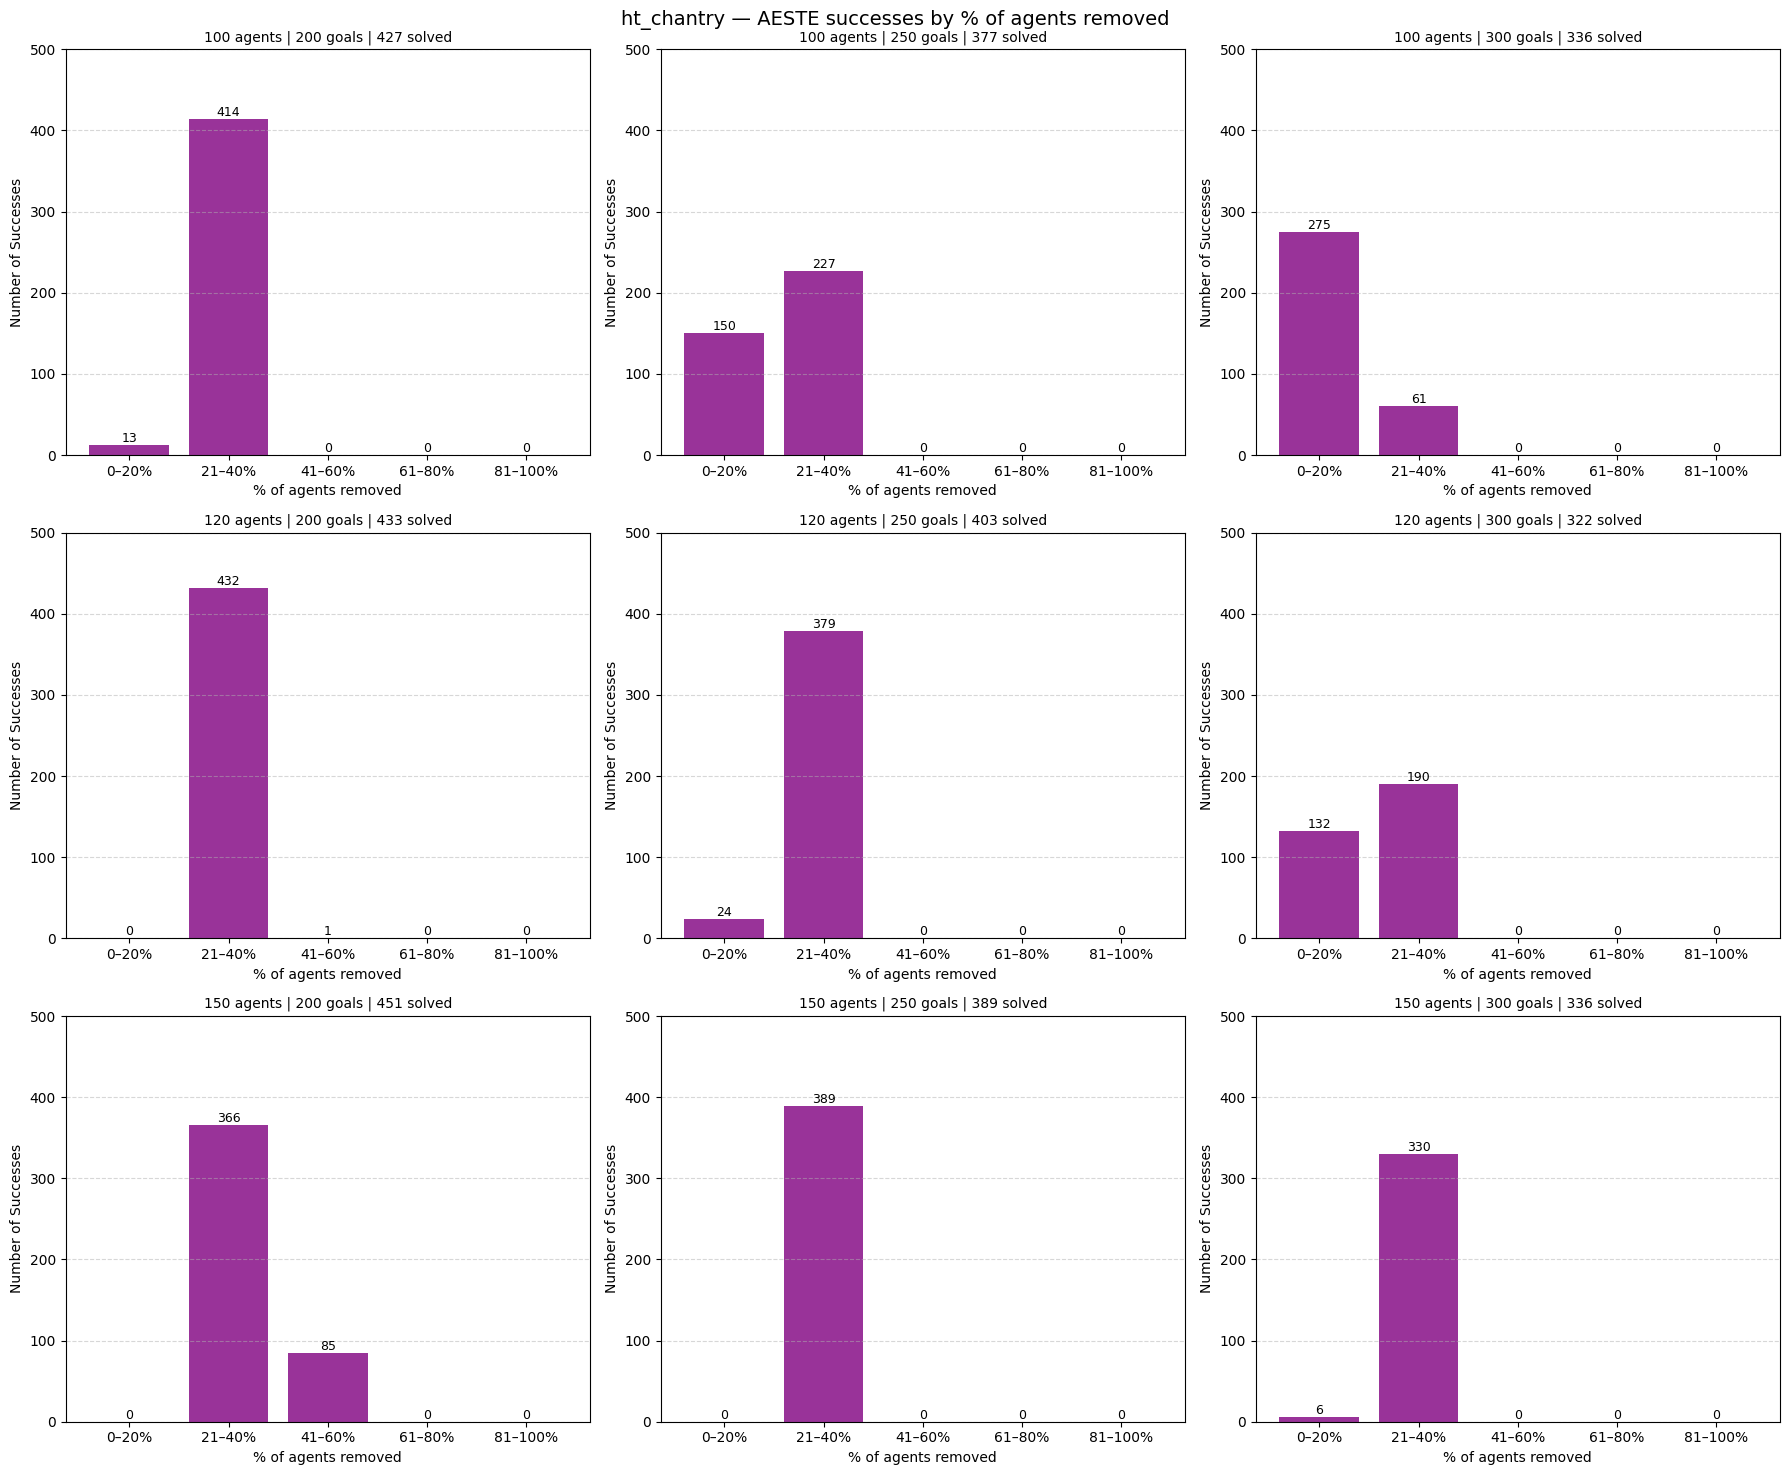

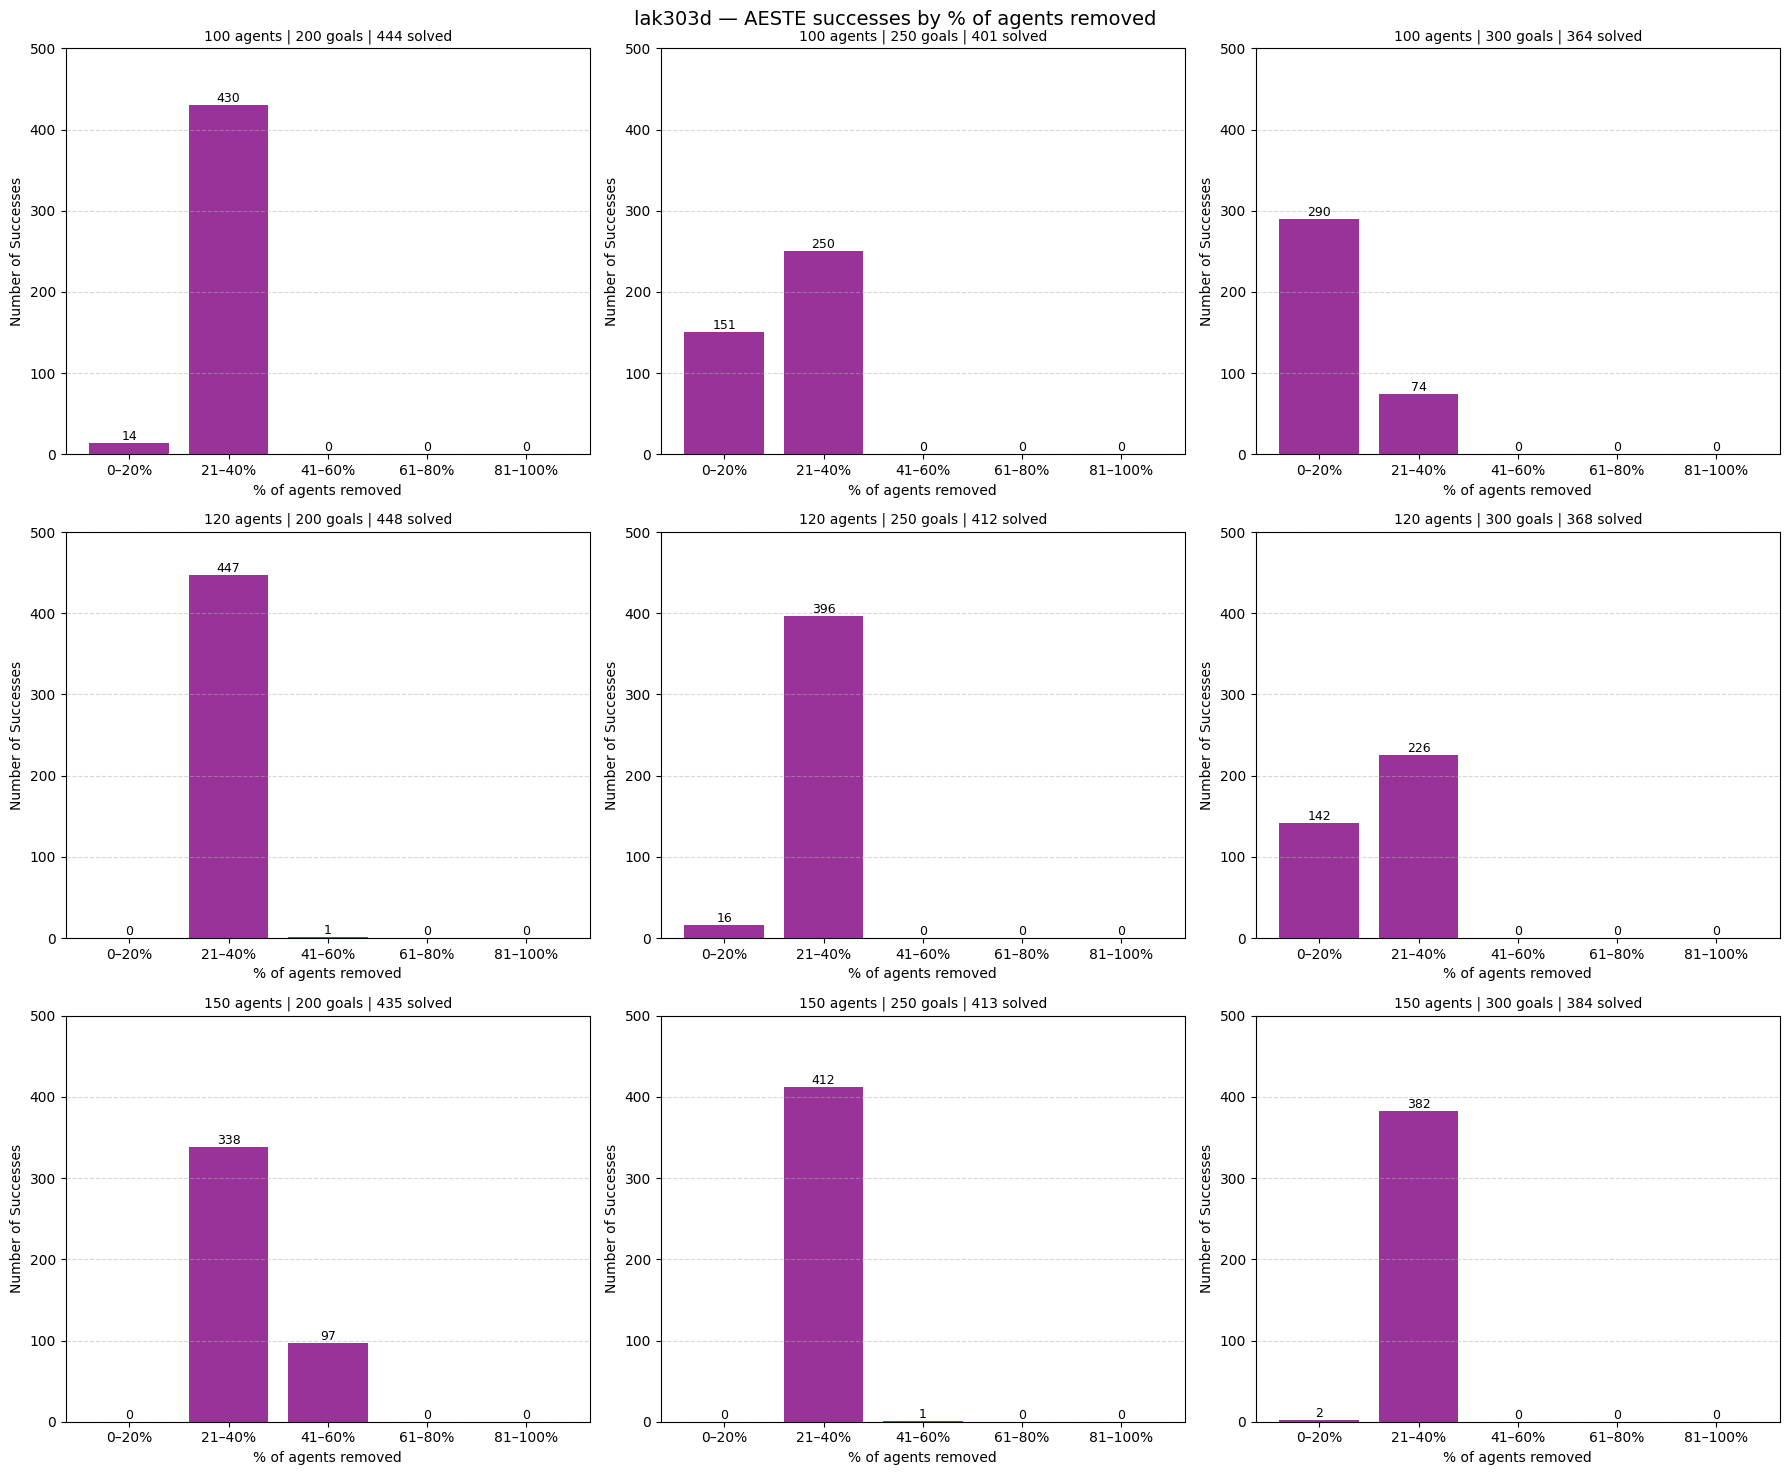

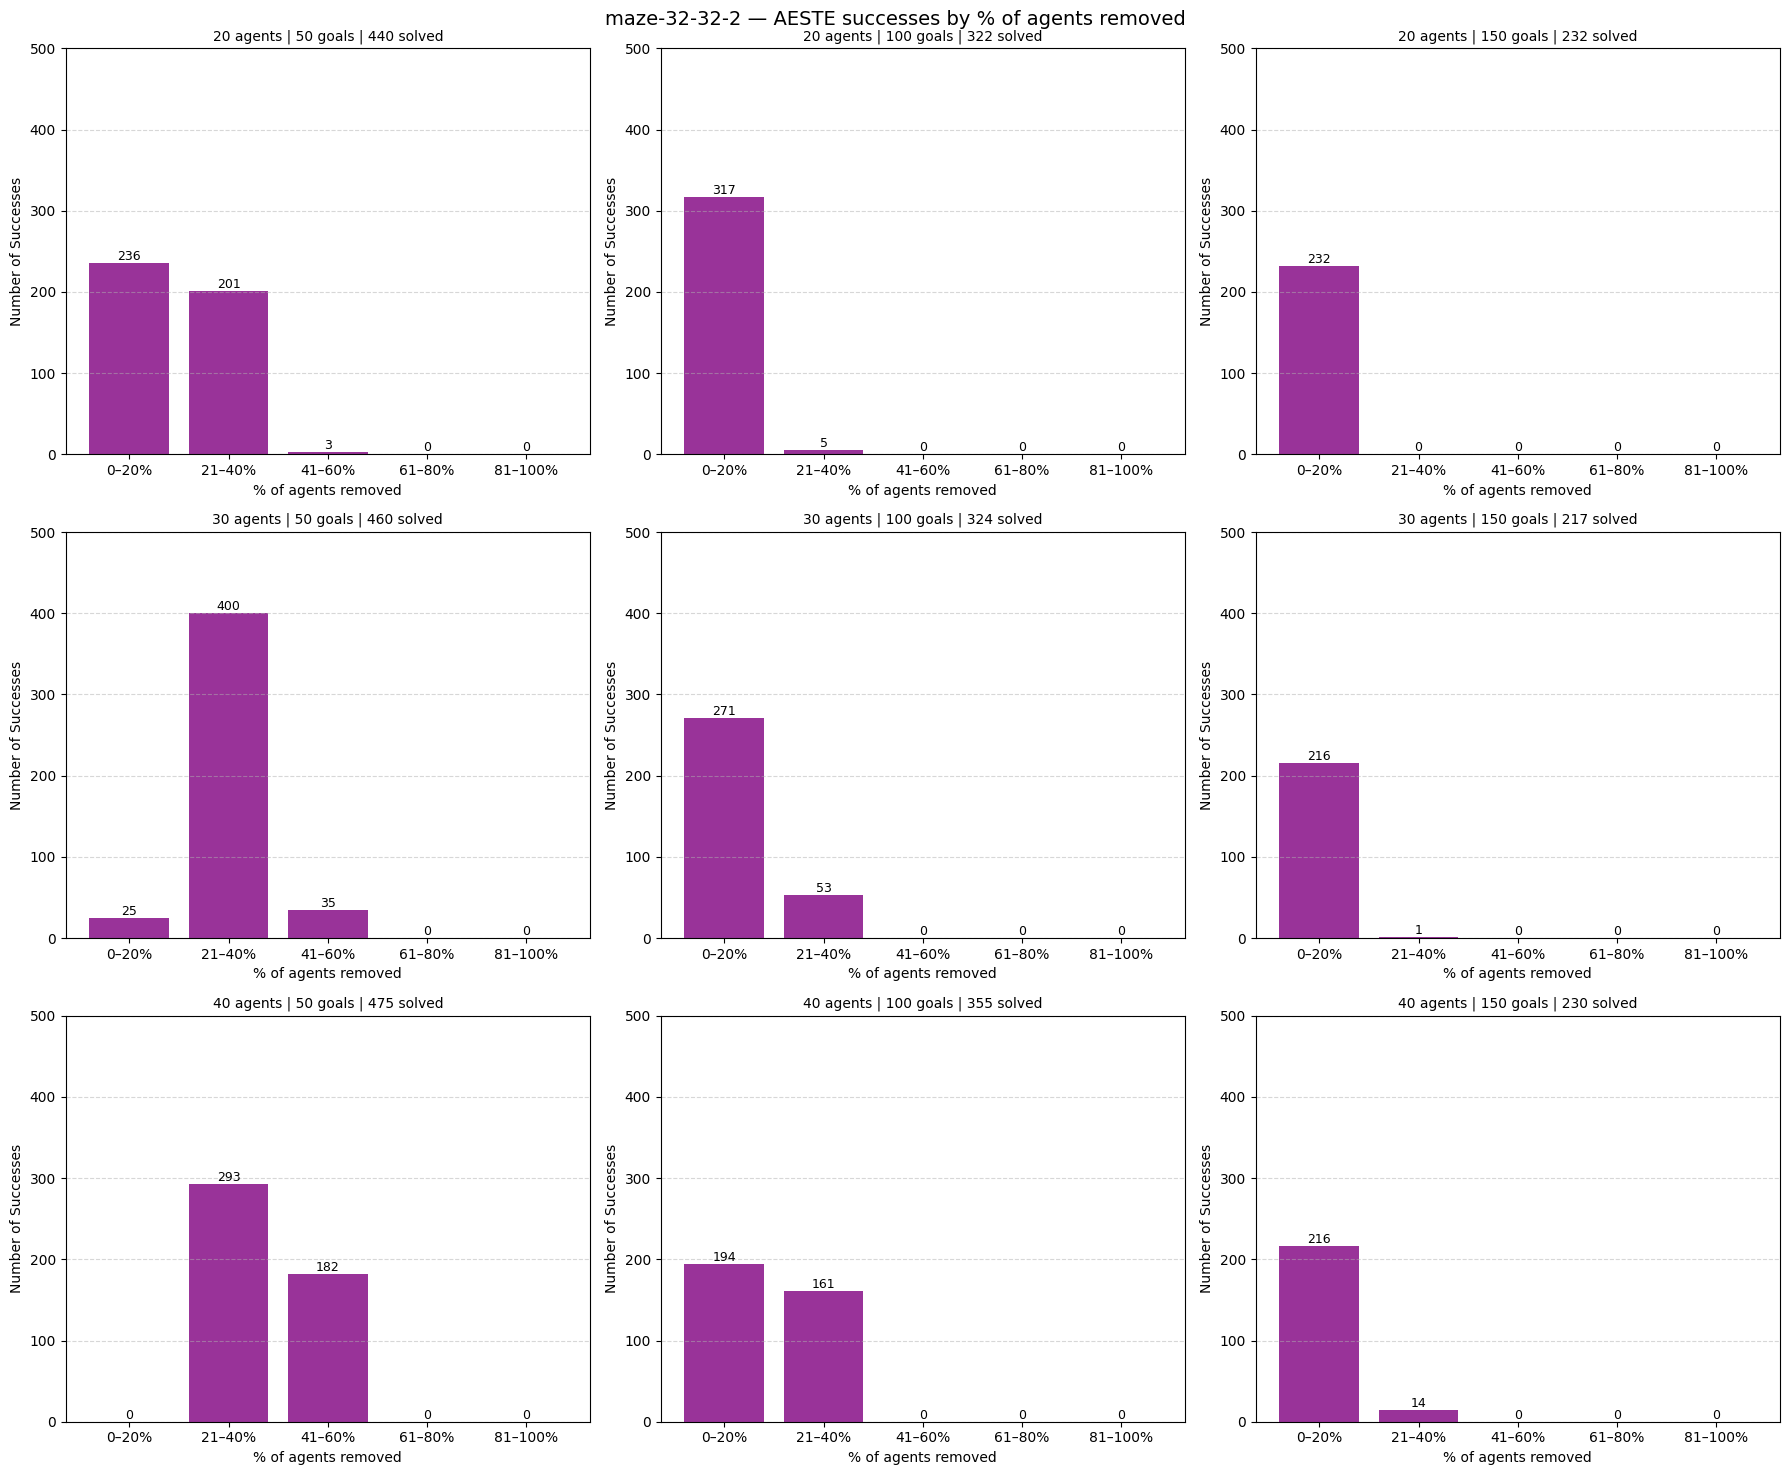

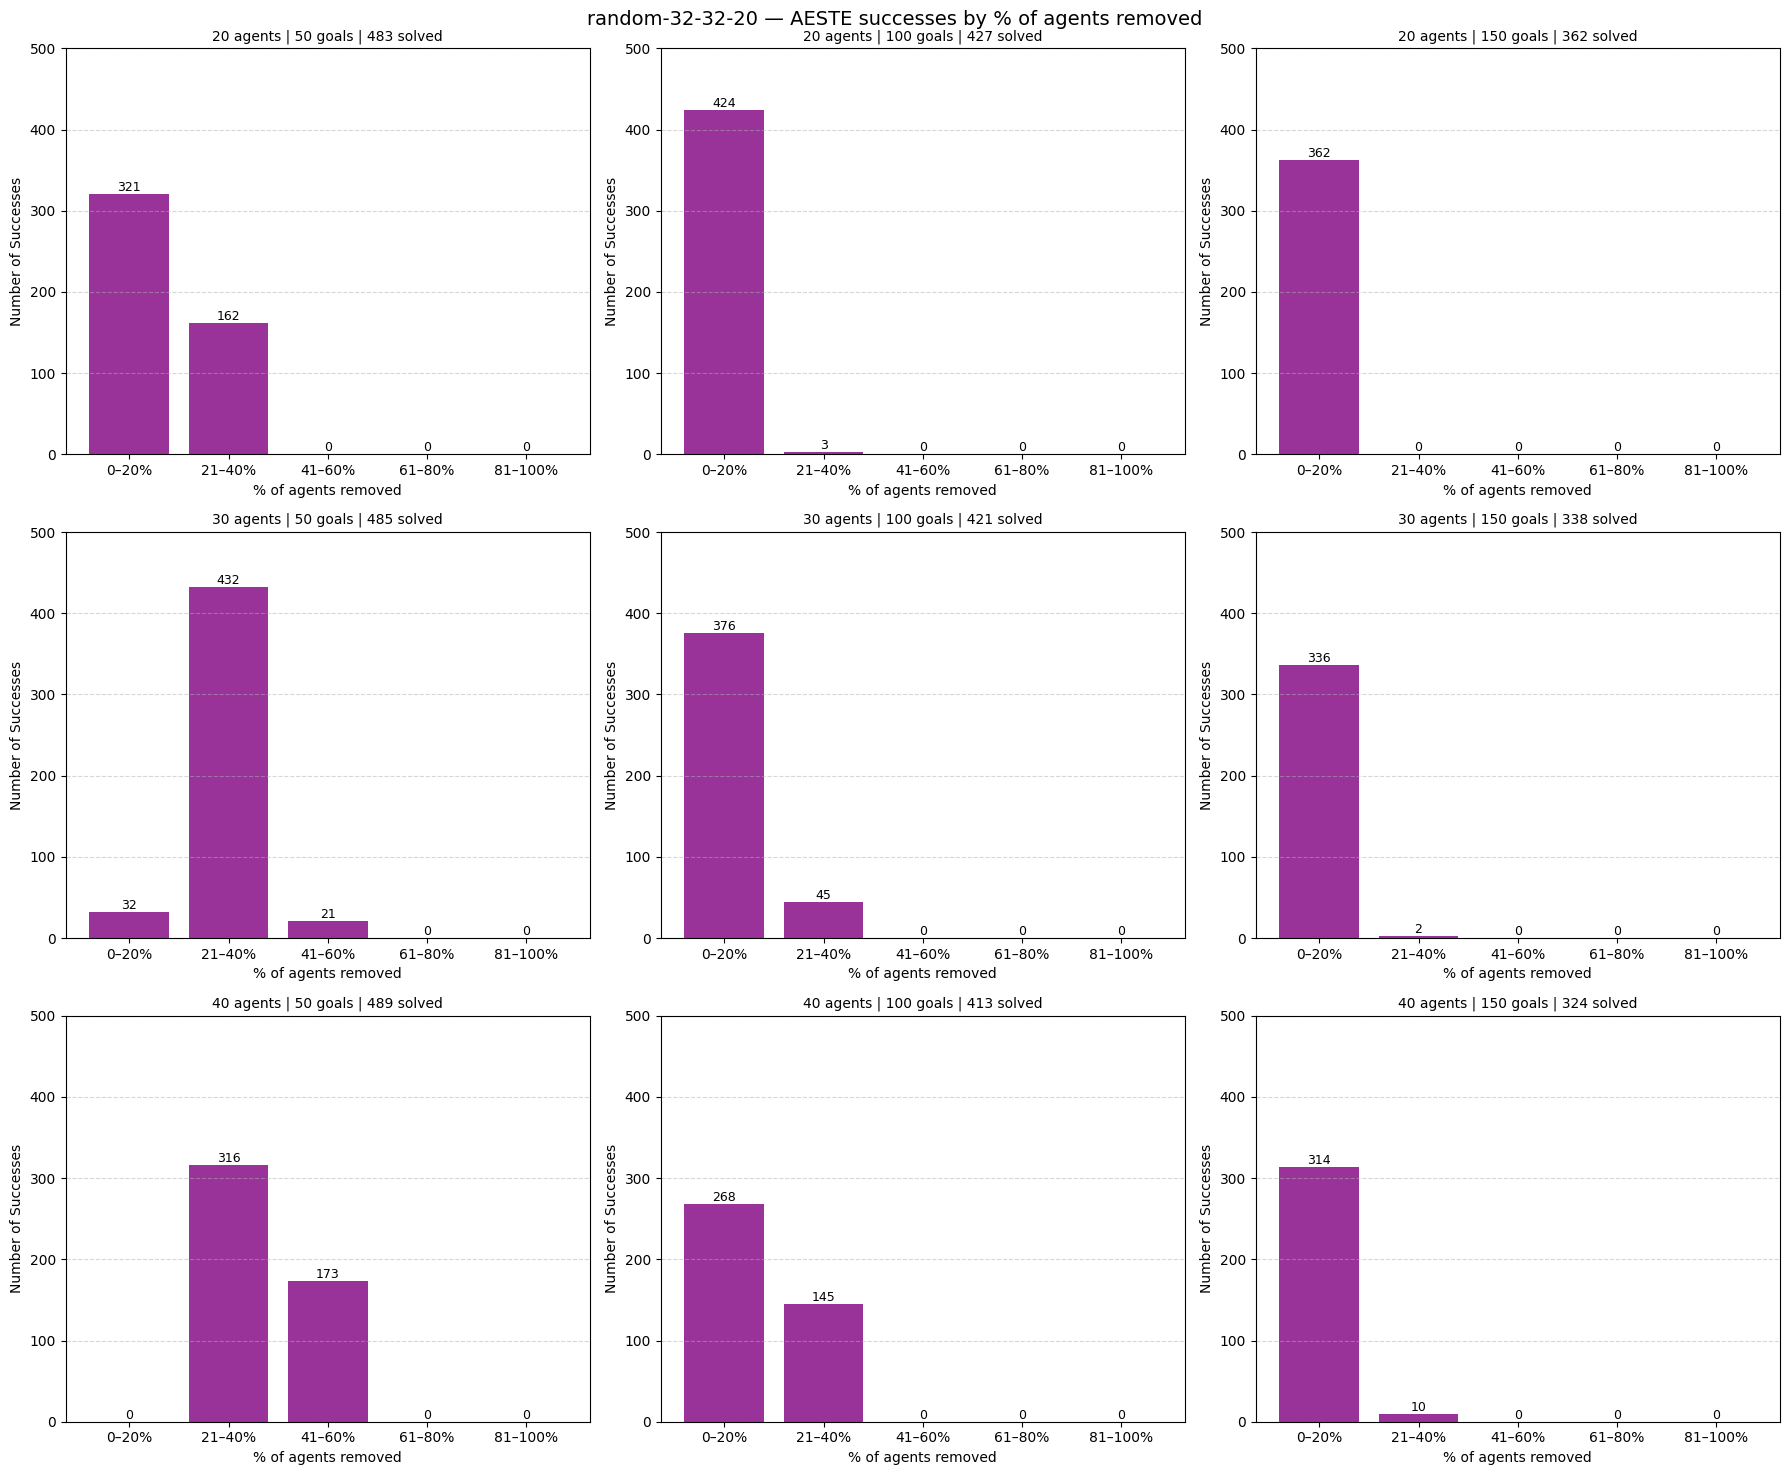

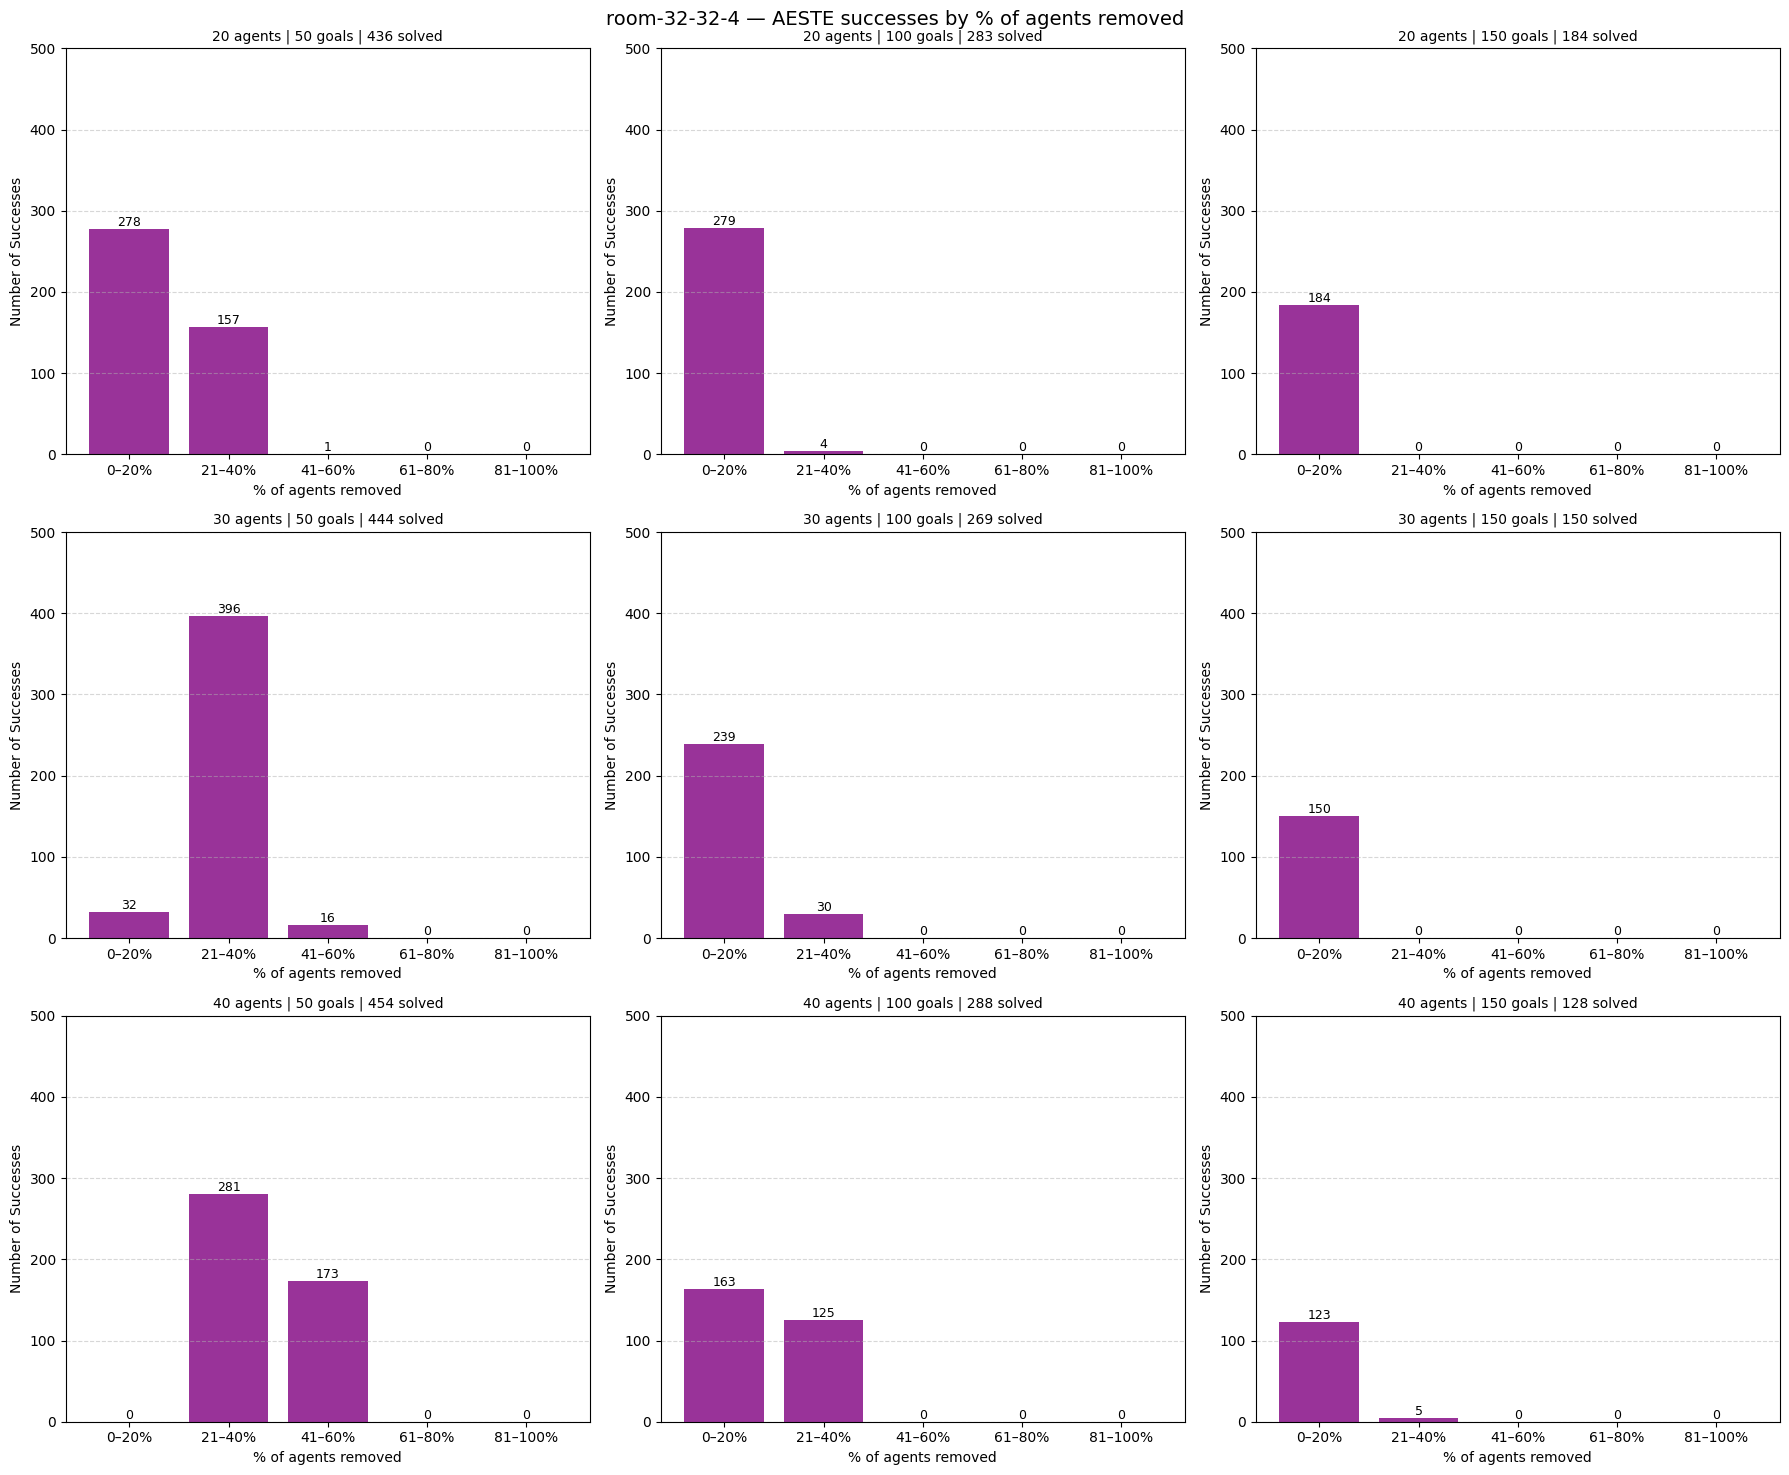

In [8]:
PCT_BINS   = [0, 20, 40, 60, 80, 100]
PCT_LABELS = ["0–20%", "21–40%", "41–60%", "61–80%", "81–100%"]

def plot_aeste_by_pct(dmap, map_name):
    agent_vals, goal_vals, subs = grid_axes(dmap)
    nrows, ncols = len(agent_vals), len(goal_vals)

    sm_counts = {}
    for r in range(nrows):
        for c in range(ncols):
            sub = subs[(r, c)]
            sm = sub[sub["How To Remove"] == "AESTE"].copy()
            if sm.empty:
                sm_counts[(r, c)] = None
                continue
            sm["pct_removed"] = sm["Number of removed agents"] / sm["Number of agents"] * 100
            sm["pct_bin"] = pd.cut(sm["pct_removed"], bins=PCT_BINS, labels=PCT_LABELS, include_lowest=True)
            counts = (sm[sm["success"]].groupby("pct_bin", observed=False)["Instance"].count()
                      .reindex(PCT_LABELS, fill_value=0))
            sm_counts[(r, c)] = (sm, counts)

    gmax = max((counts.max() for v in sm_counts.values() if v is not None for _, counts in [v]), default=1)
    y_max, yticks = _nice_axis(gmax)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    fig.suptitle(f"{map_name} — AESTE successes by % of agents removed", fontsize=14)
    for r, a in enumerate(agent_vals):
        for c, g in enumerate(goal_vals):
            ax = axes[r][c]
            v = sm_counts[(r, c)]
            if v is None:
                ax.set_title(f"{a} agents | {g} goals\n(no data)", fontsize=10)
                ax.axis("off")
                continue
            sm, counts = v
            bars = ax.bar(PCT_LABELS, counts.values, color=STRATEGY_STYLE["AESTE"]["color"], alpha=0.8)
            ax.bar_label(bars, fontsize=9)
            ax.set_title(f"{a} agents | {g} goals | {sm['success'].sum()} solved", fontsize=10)
            ax.set_xlabel("% of agents removed", fontsize=10)
            ax.set_ylabel("Number of Successes", fontsize=10)
            ax.set_ylim(0, y_max)
            ax.set_yticks(yticks)
            ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_aeste_by_pct(df_all[df_all["Map"] == m], m)

## DelayExclusion vs RandomExclusion — Mean Solved%

In [9]:
# DelayExclusion vs RandomExclusion solved %, pooled per map, with two-tailed McNemar
# Paired on (Instance, agents, goals, removed agents) — same instances at the same removal counts
keys = ["Instance", "Number of agents", "Number of goals", "Number of removed agents"]

rows = []
for m in maps:
    dm = df_all[df_all["Map"] == m]
    de = dm[dm["How To Remove"] == "DelayExclusion"][keys + ["success"]]
    ra = dm[dm["How To Remove"] == "RandomExclusion"][keys + ["success"]]
    mg = de.merge(ra, on=keys, suffixes=("_d", "_r"))

    b = int((mg["success_d"] & ~mg["success_r"]).sum())   # Delay solved, Random not
    c = int((~mg["success_d"] & mg["success_r"]).sum())    # Random solved, Delay not
    p = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0

    stats = {"DelayExclusion": mg["success_d"].mean() * 100,
             "RandomExclusion": mg["success_r"].mean() * 100}
    for s, solved in stats.items():
        rows.append({"Map": m, "Strategy": s,
                     "Mean Solved%": f"{solved:.1f}%",
                     "McNemar p": sig_mark(p) if s == "DelayExclusion" else ""})
delay_vs_random = pd.DataFrame(rows)
delay_vs_random

,Map,Strategy,Mean Solved%,McNemar p
0,den520d,DelayExclusion,90.2%,7.18e-04 ✓
1,den520d,RandomExclusion,89.4%,
2,ht_chantry,DelayExclusion,72.9%,4.86e-01 ✗
3,ht_chantry,RandomExclusion,73.1%,
4,lak303d,DelayExclusion,77.5%,1.19e-02 ✓
5,lak303d,RandomExclusion,78.4%,
6,maze-32-32-2,DelayExclusion,68.4%,1.56e-12 ✓
7,maze-32-32-2,RandomExclusion,66.1%,
8,random-32-32-20,DelayExclusion,88.2%,4.18e-14 ✓
9,random-32-32-20,RandomExclusion,86.4%,


## Solved %: winner (Delay/Random) vs AESTE — 7 bars (all maps)

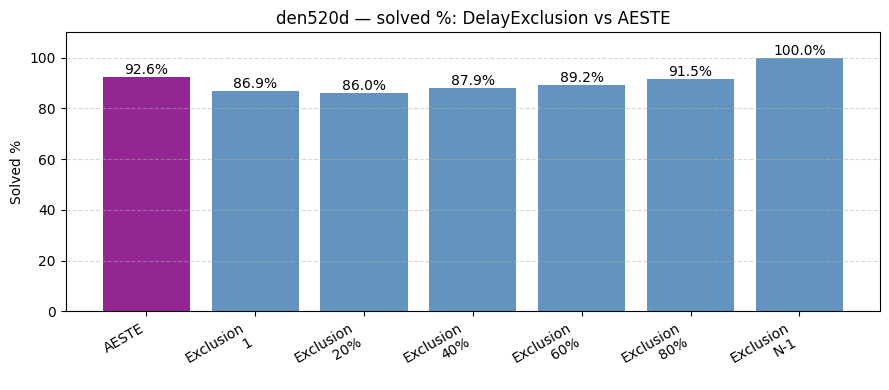

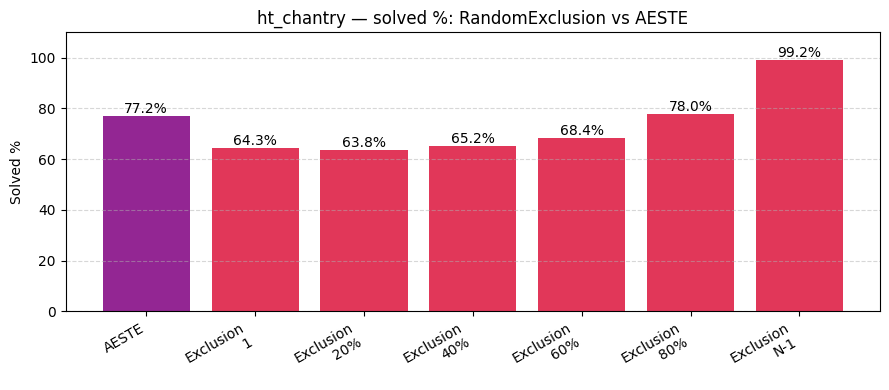

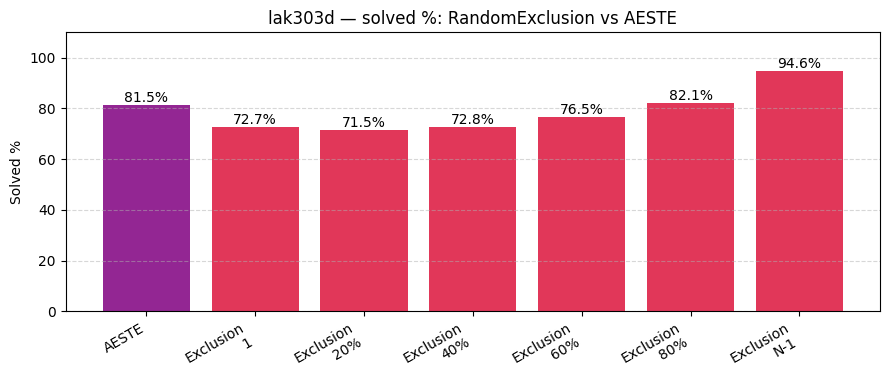

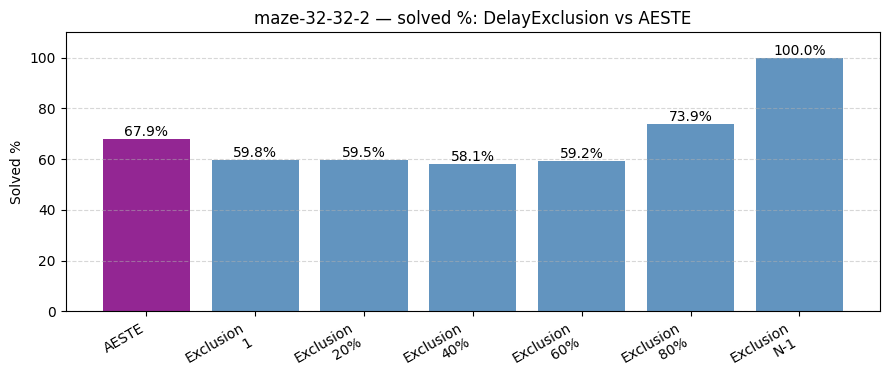

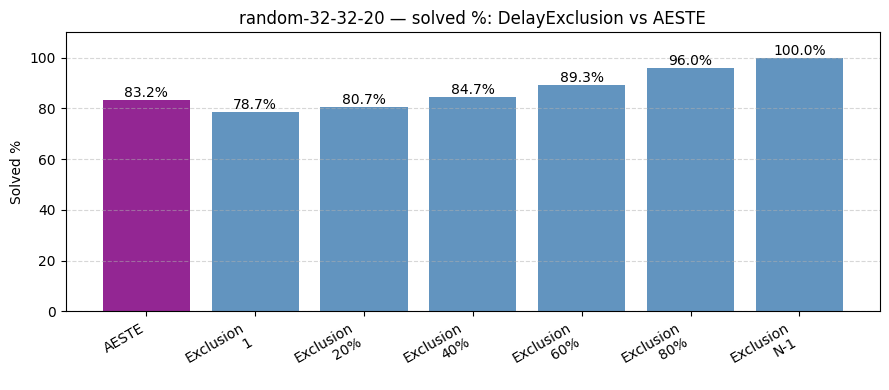

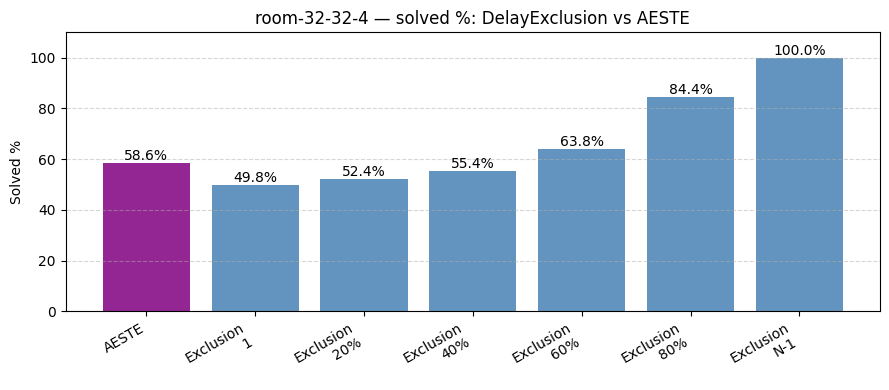

In [10]:
def plot_solved_pct(ctx, map_name):
    sm_df = ctx["sm_df"]; total = ctx["aeste_total"]
    LEVEL_ORDER = ctx["LEVEL_ORDER"]; winner_by_lvl = ctx["winner_by_lvl"]
    winner = ctx["winner"]; win_color = ctx["win_color"]

    fig, ax = plt.subplots(figsize=(9, 4))
    aeste_pct = sm_df["Online SST"].notna().sum() / total * 100 if total else 0
    labels = ["AESTE"] + [f"Exclusion\n{lvl}" for lvl in LEVEL_ORDER]
    values = [aeste_pct] + [
        winner_by_lvl[lvl]["Online SST"].notna().sum() / len(winner_by_lvl[lvl]) * 100
        if len(winner_by_lvl[lvl]) else 0
        for lvl in LEVEL_ORDER
    ]
    colors = [STRATEGY_STYLE["AESTE"]["color"]] + [win_color] * 6
    bars = ax.bar(labels, values, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=10)
    ax.set_title(f"{map_name} — solved %: {winner} vs AESTE", fontsize=12)
    ax.set_ylabel("Solved %", fontsize=10)
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", labelrotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_solved_pct(ctx_by_map[m], m)

## Avg Online SST on co-solved instances: winner vs AESTE (all maps)

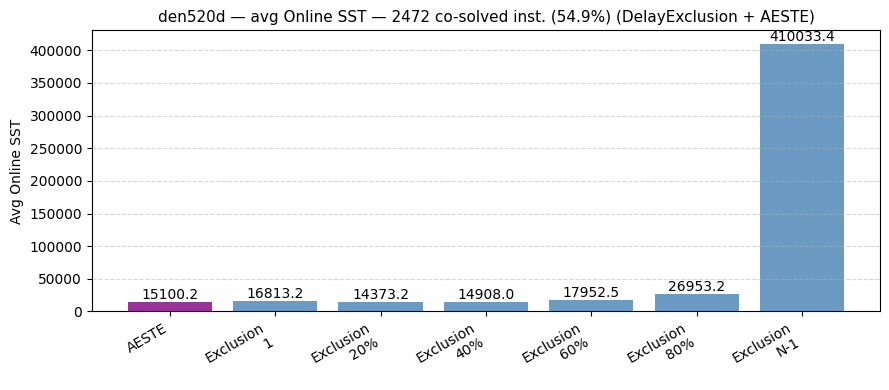

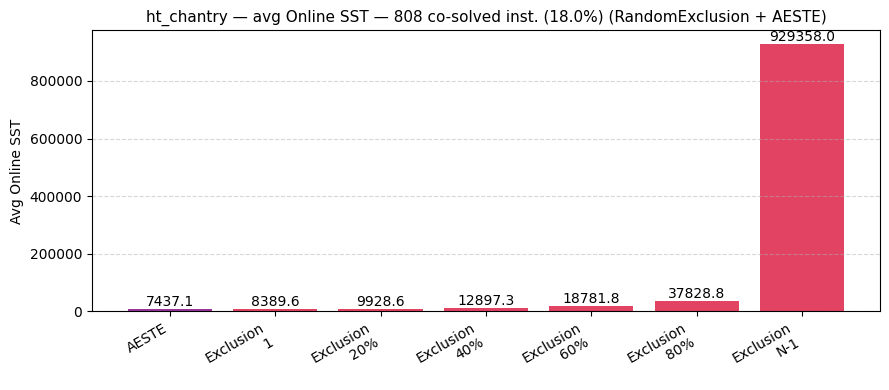

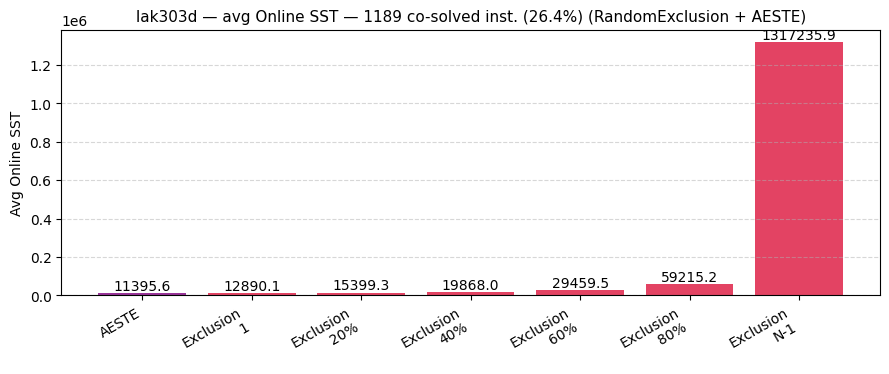

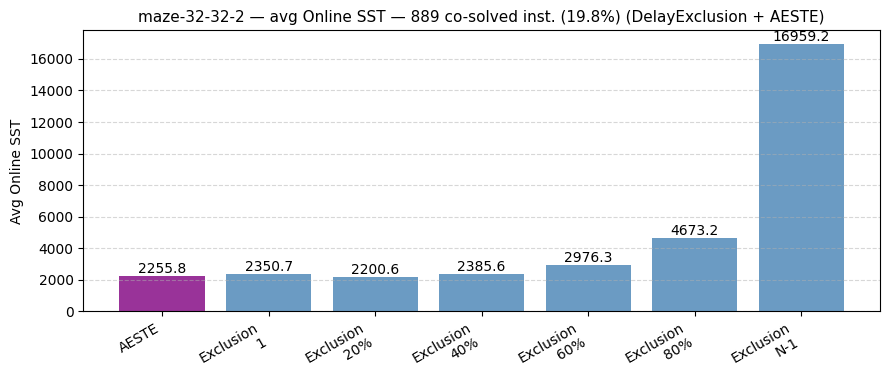

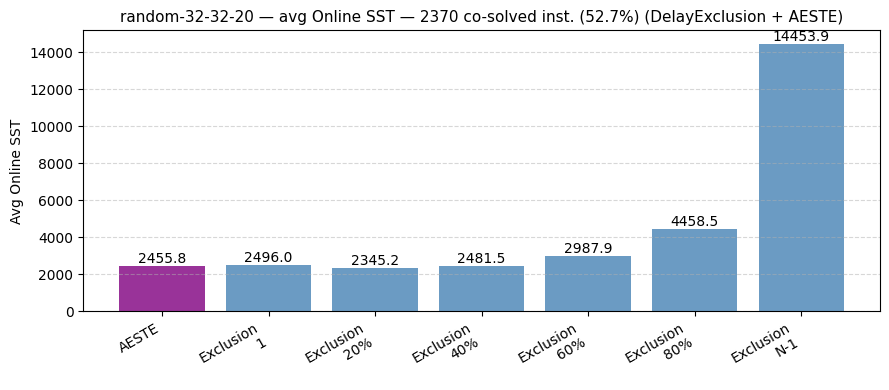

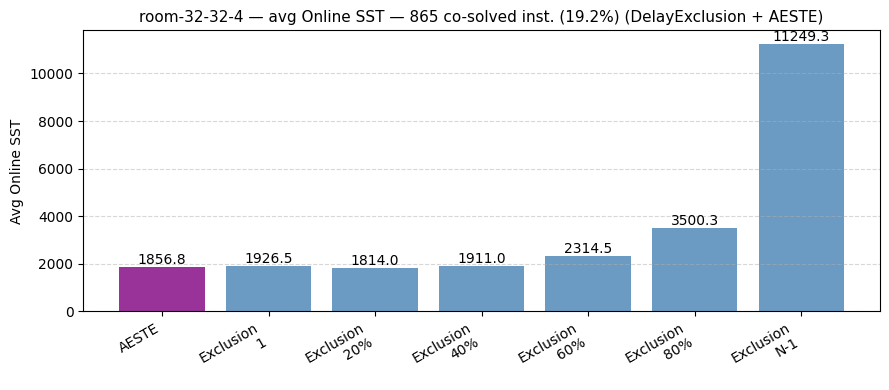

In [11]:
def plot_cosolved_sst(ctx, map_name):
    cos = ctx["cosolved"]; LEVEL_ORDER = ctx["LEVEL_ORDER"]
    win_color = ctx["win_color"]; winner = ctx["winner"]; co_pct = ctx["co_pct"]

    fig, ax = plt.subplots(figsize=(9, 4))
    specs = [("AESTE", "SST_AESTE", STRATEGY_STYLE["AESTE"]["color"])] + \
            [(f"Exclusion\n{lvl}", f"SST_{lvl}", win_color) for lvl in LEVEL_ORDER]
    if not cos.empty:
        lbls = [s[0] for s in specs if s[1] in cos.columns]
        vals = [cos[s[1]].mean() for s in specs if s[1] in cos.columns]
        clrs = [s[2] for s in specs if s[1] in cos.columns]
        bars = ax.bar(lbls, vals, color=clrs, alpha=0.8)
        ax.bar_label(bars, fmt="%.1f", fontsize=10)
        ax.set_title(f"{map_name} — avg Online SST — {len(cos)} co-solved inst. ({co_pct:.1f}%) ({winner} + AESTE)", fontsize=11)
    else:
        ax.set_title(f"{map_name} — avg Online SST (no co-solved instances)", fontsize=11)
    ax.set_ylabel("Avg Online SST", fontsize=10)
    ax.tick_params(axis="x", labelrotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_cosolved_sst(ctx_by_map[m], m)

## Avg Runtime on co-solved instances: winner vs AESTE (all maps)

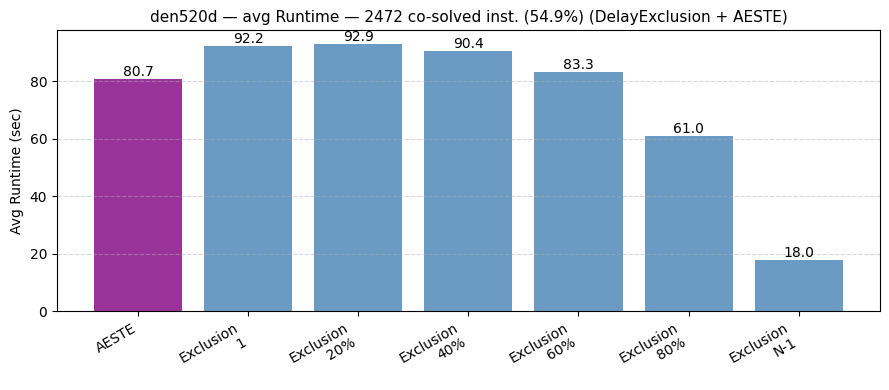

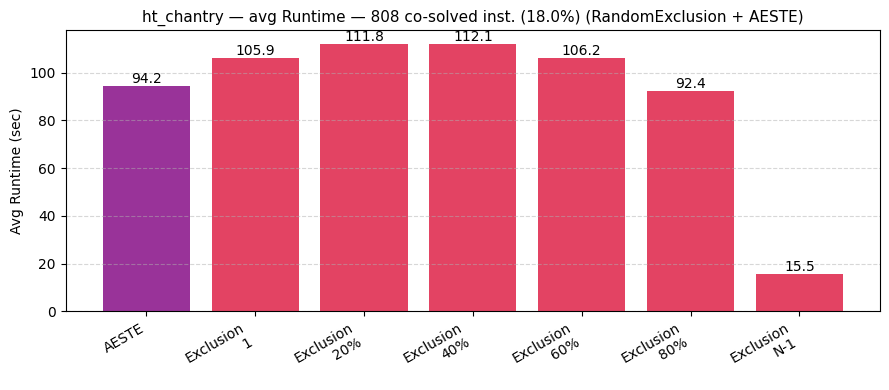

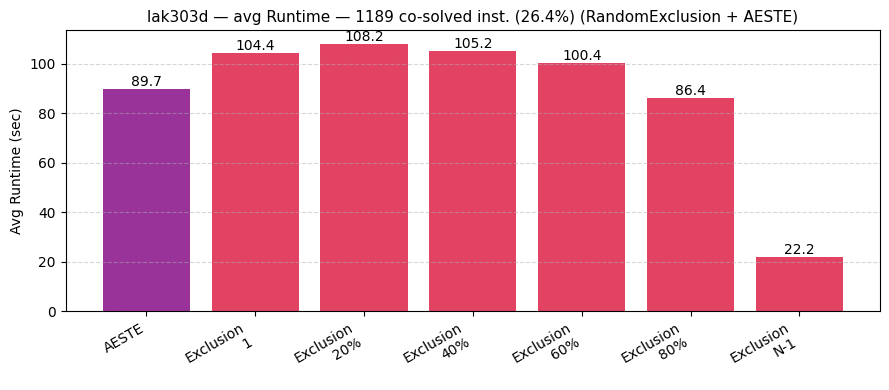

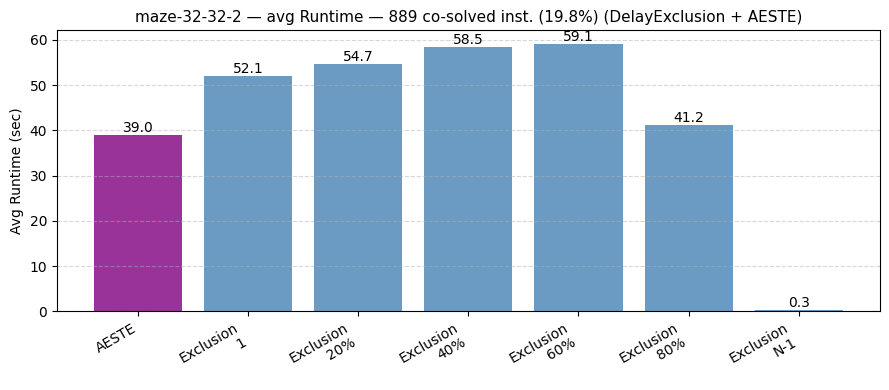

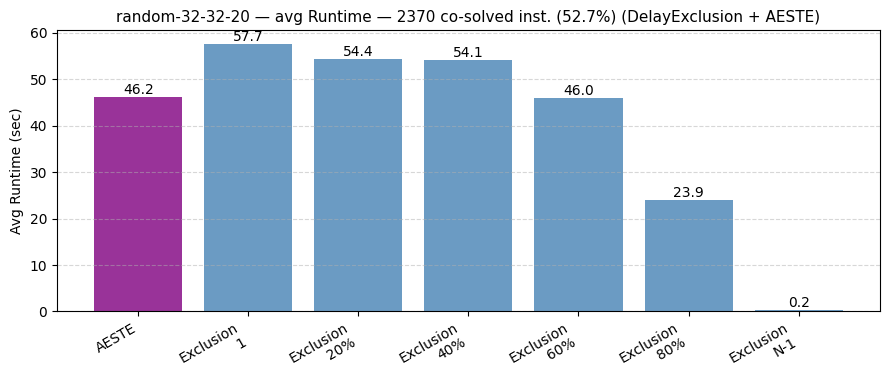

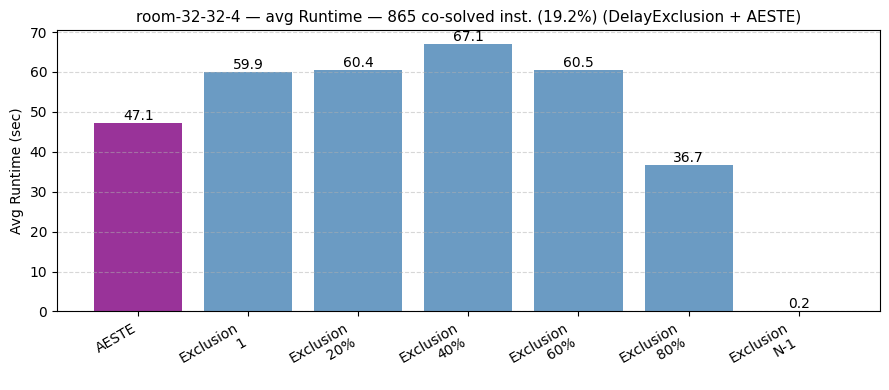

In [12]:
def plot_cosolved_runtime(ctx, map_name):
    cos = ctx["cosolved"]; LEVEL_ORDER = ctx["LEVEL_ORDER"]
    win_color = ctx["win_color"]; winner = ctx["winner"]; co_pct = ctx["co_pct"]

    fig, ax = plt.subplots(figsize=(9, 4))
    specs = [("AESTE", "RT_AESTE", STRATEGY_STYLE["AESTE"]["color"])] + \
            [(f"Exclusion\n{lvl}", f"RT_{lvl}", win_color) for lvl in LEVEL_ORDER]
    if not cos.empty:
        lbls = [s[0] for s in specs if s[1] in cos.columns]
        vals = [cos[s[1]].mean() for s in specs if s[1] in cos.columns]
        clrs = [s[2] for s in specs if s[1] in cos.columns]
        bars = ax.bar(lbls, vals, color=clrs, alpha=0.8)
        ax.bar_label(bars, fmt="%.1f", fontsize=10)
        ax.set_title(f"{map_name} — avg Runtime — {len(cos)} co-solved inst. ({co_pct:.1f}%) ({winner} + AESTE)", fontsize=11)
    else:
        ax.set_title(f"{map_name} — avg Runtime (no co-solved instances)", fontsize=11)
    ax.set_ylabel("Avg Runtime (sec)", fontsize=10)
    ax.tick_params(axis="x", labelrotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_cosolved_runtime(ctx_by_map[m], m)

## Solved instances vs agents removed (3×3 grid, all maps)

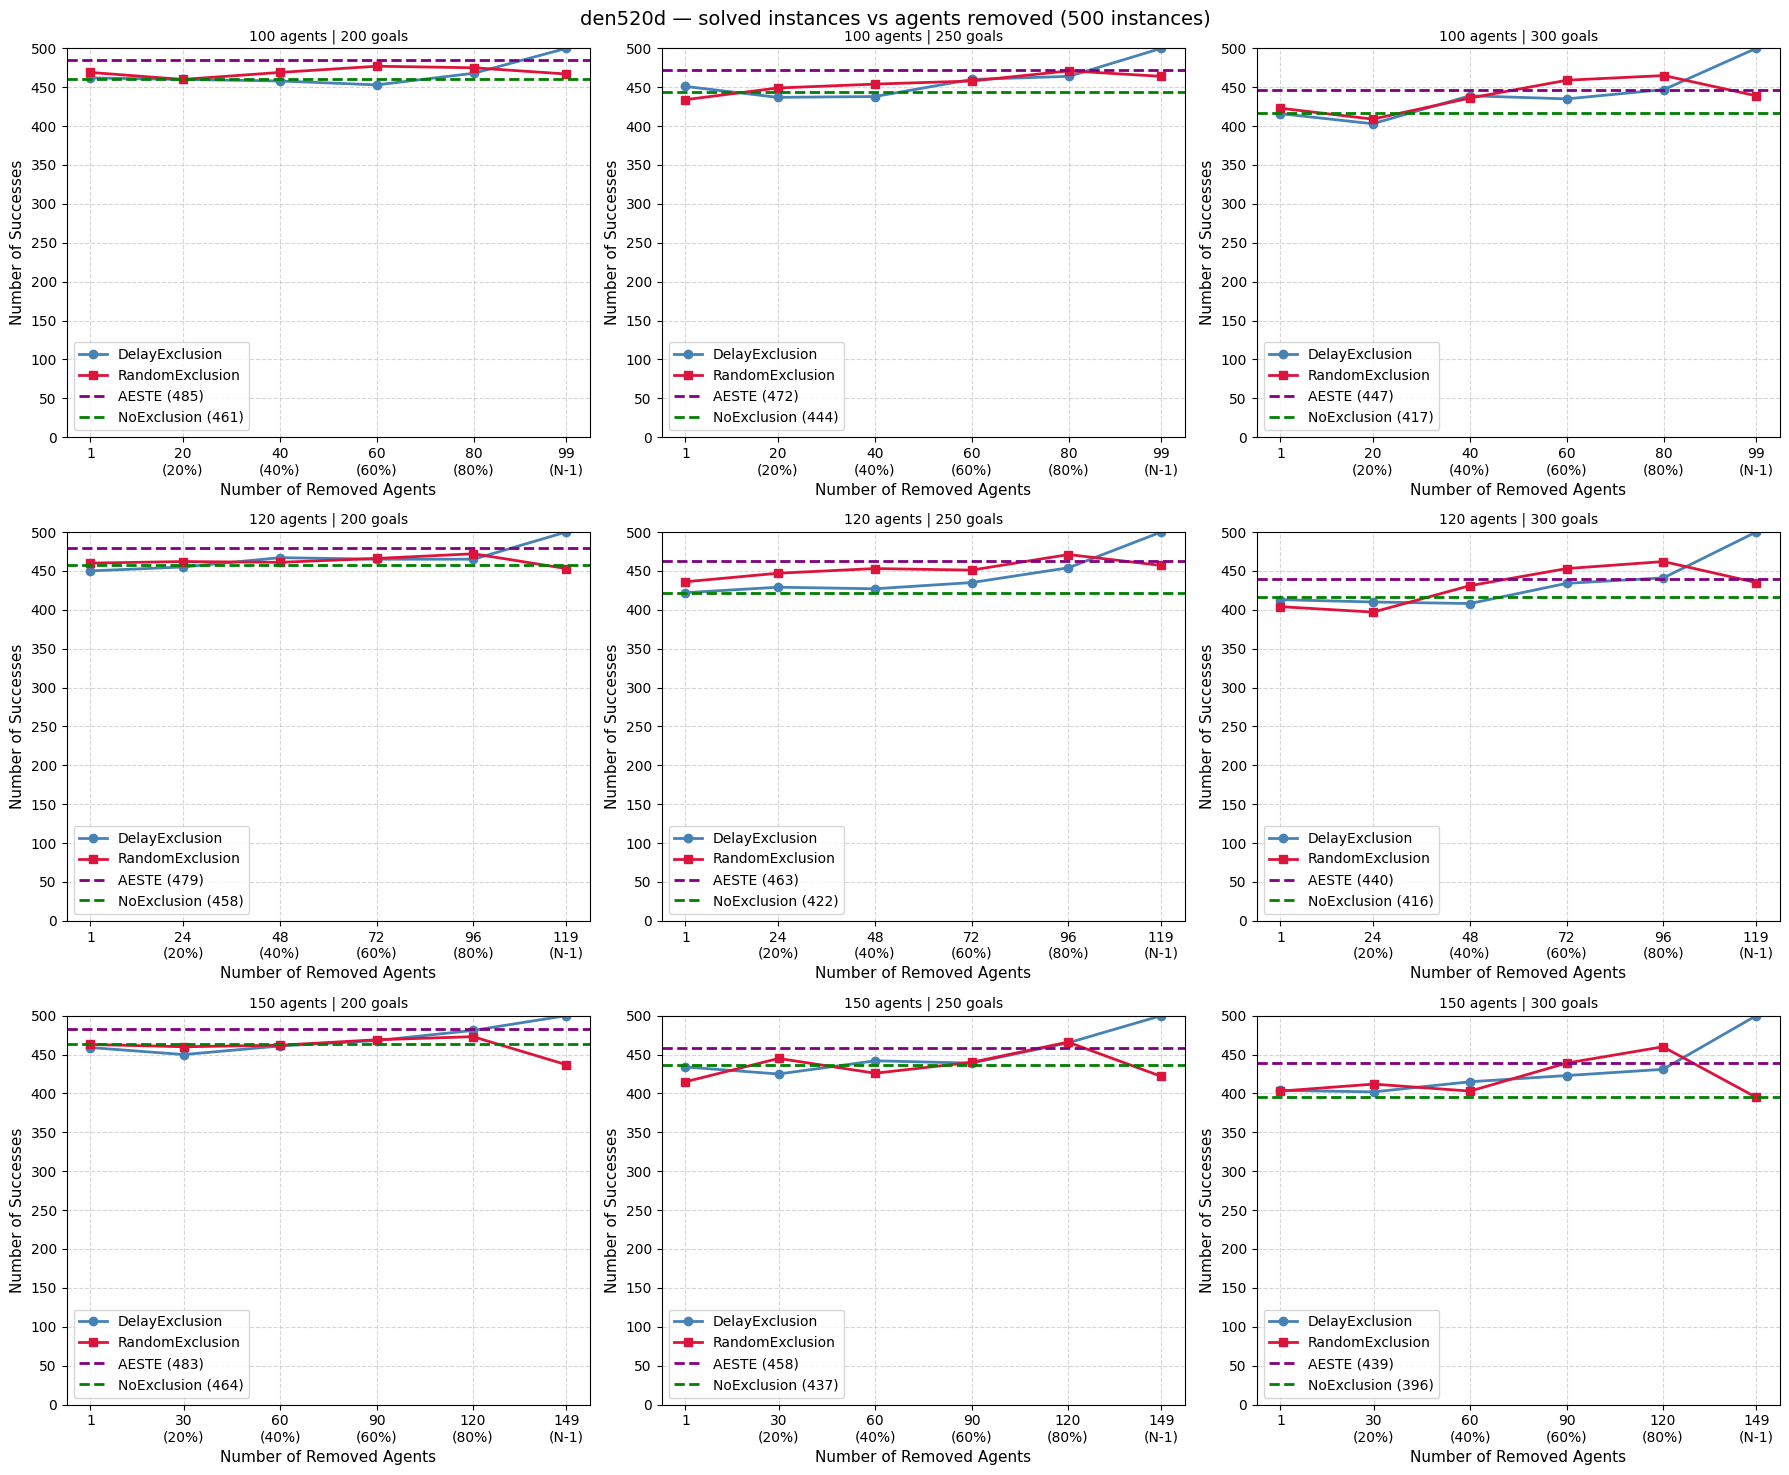

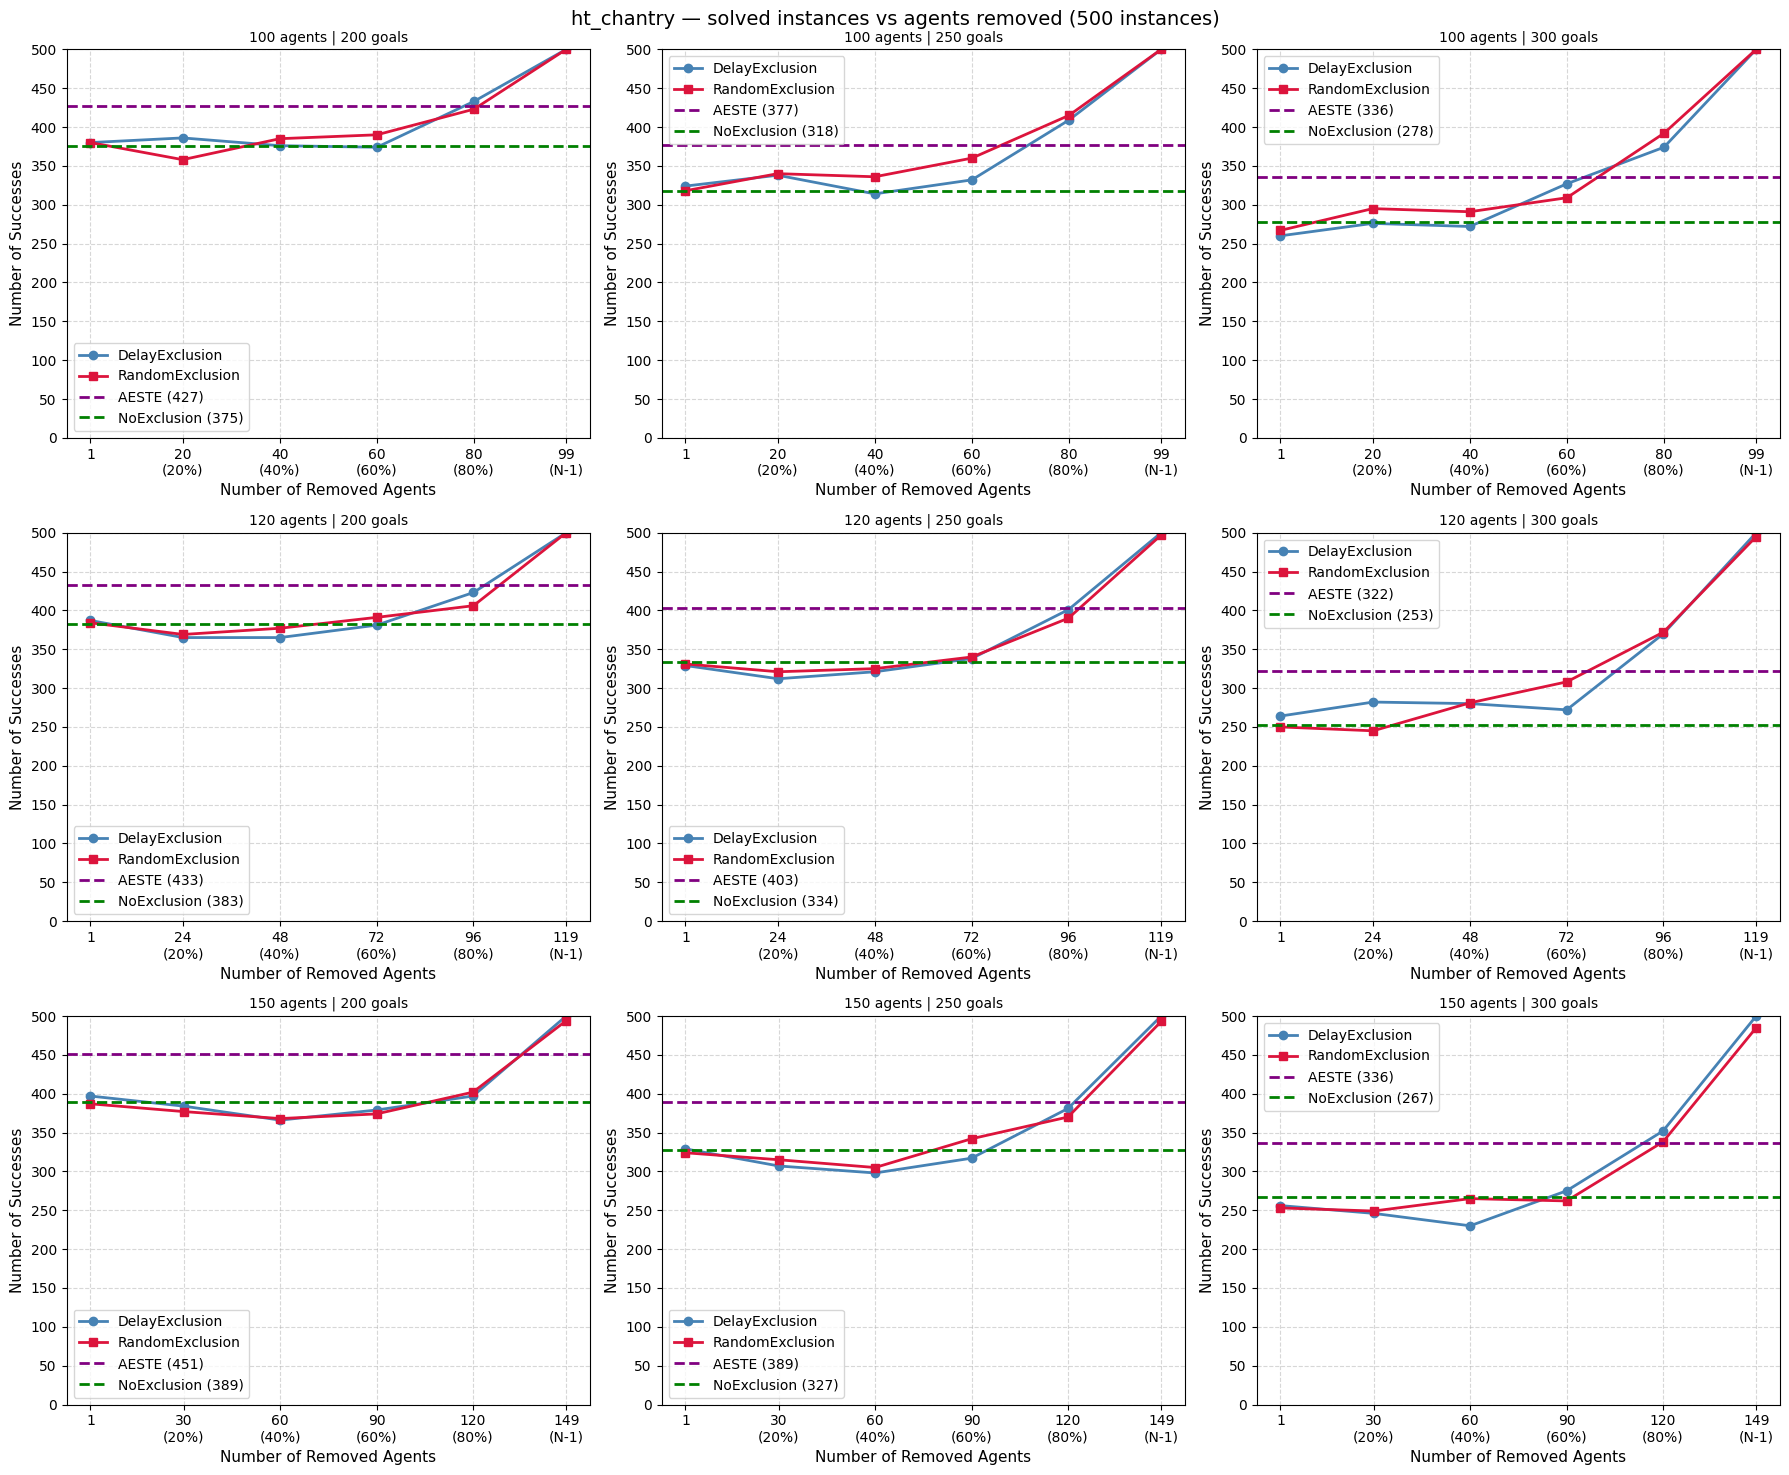

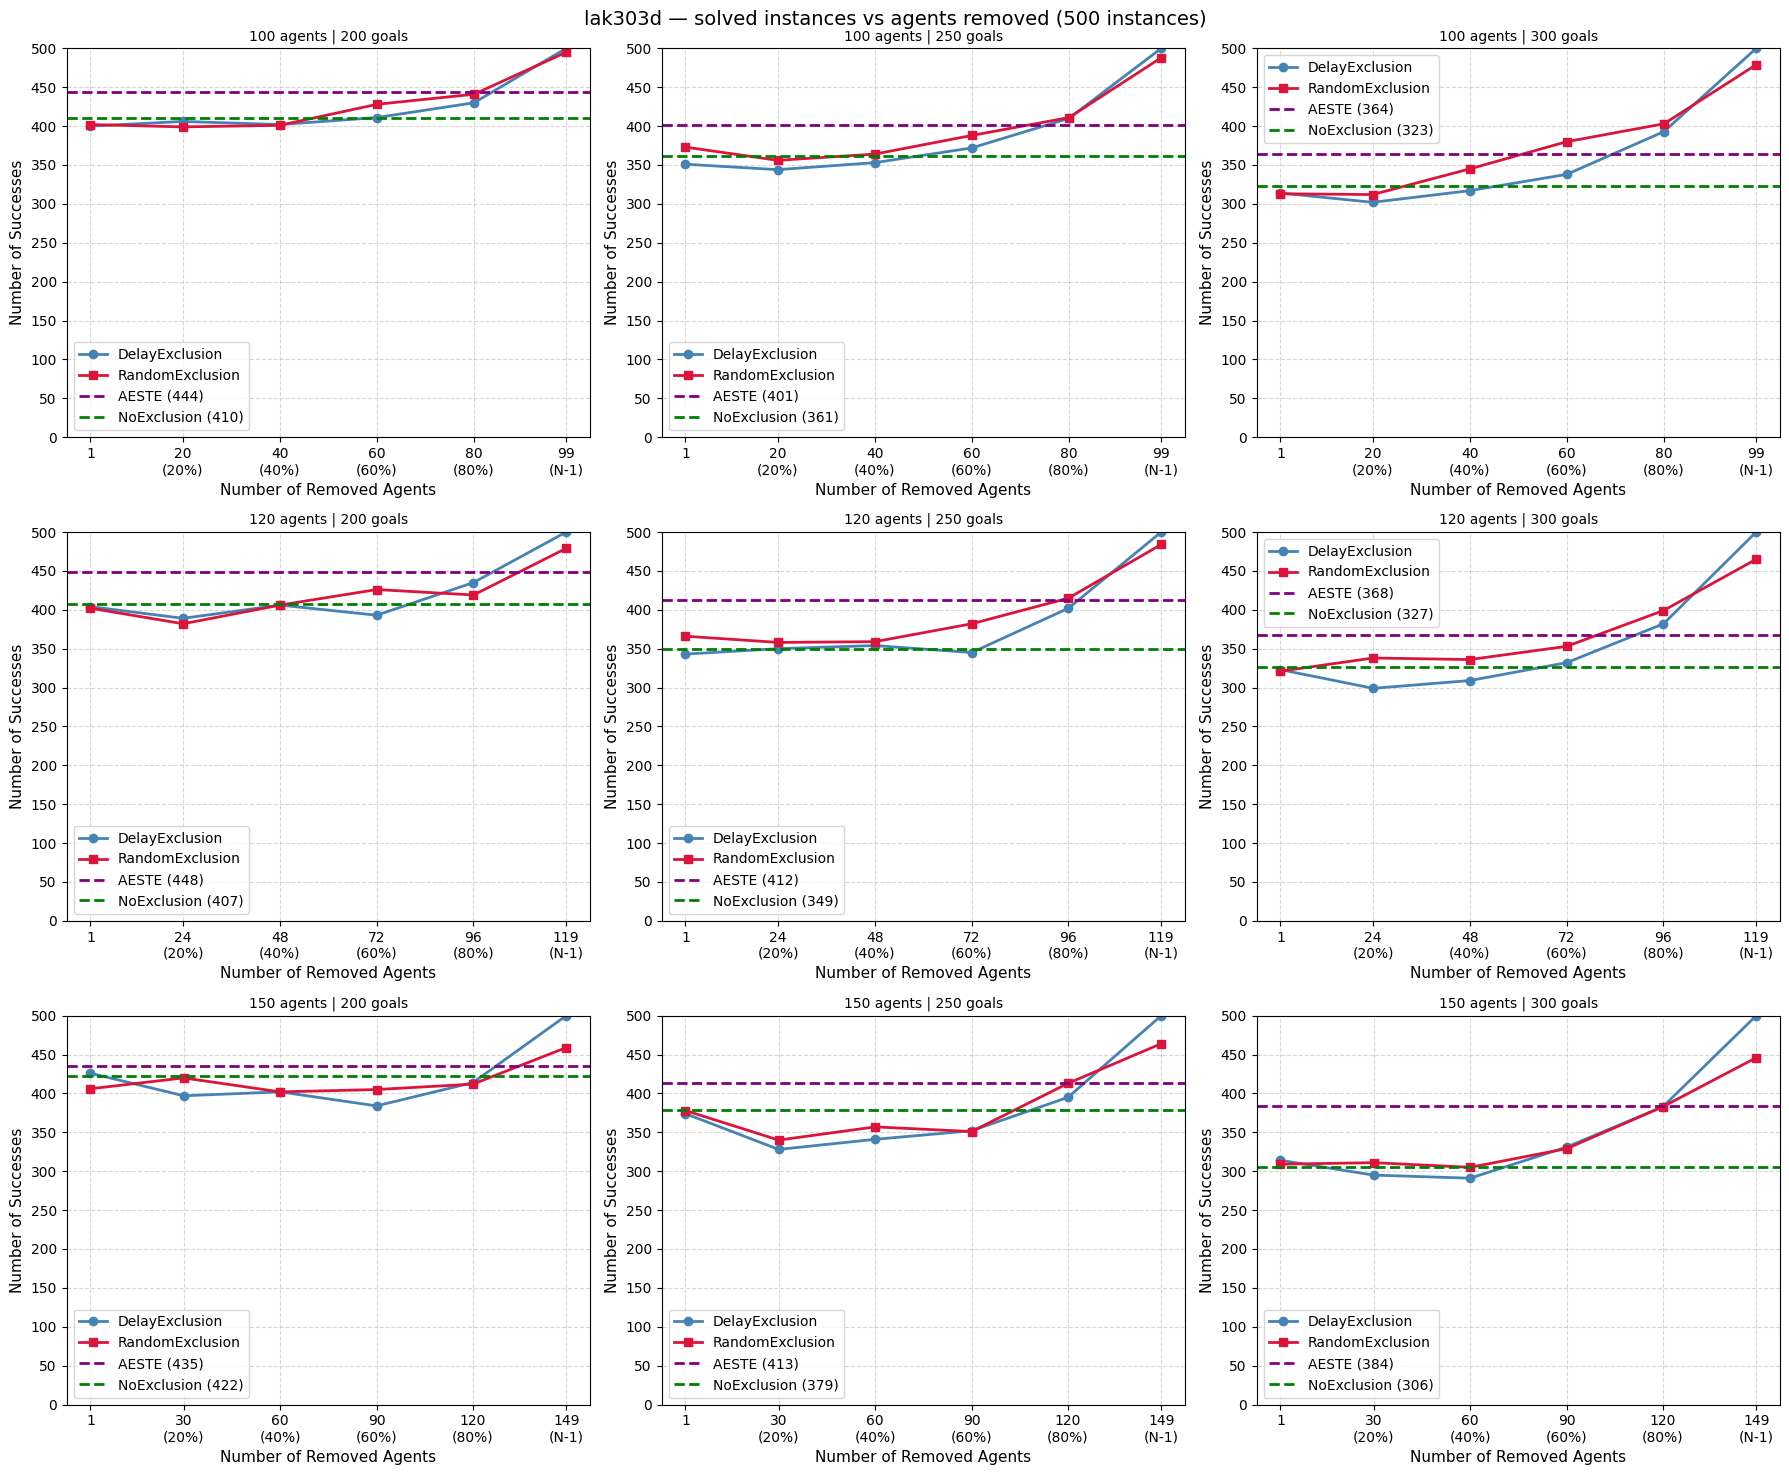

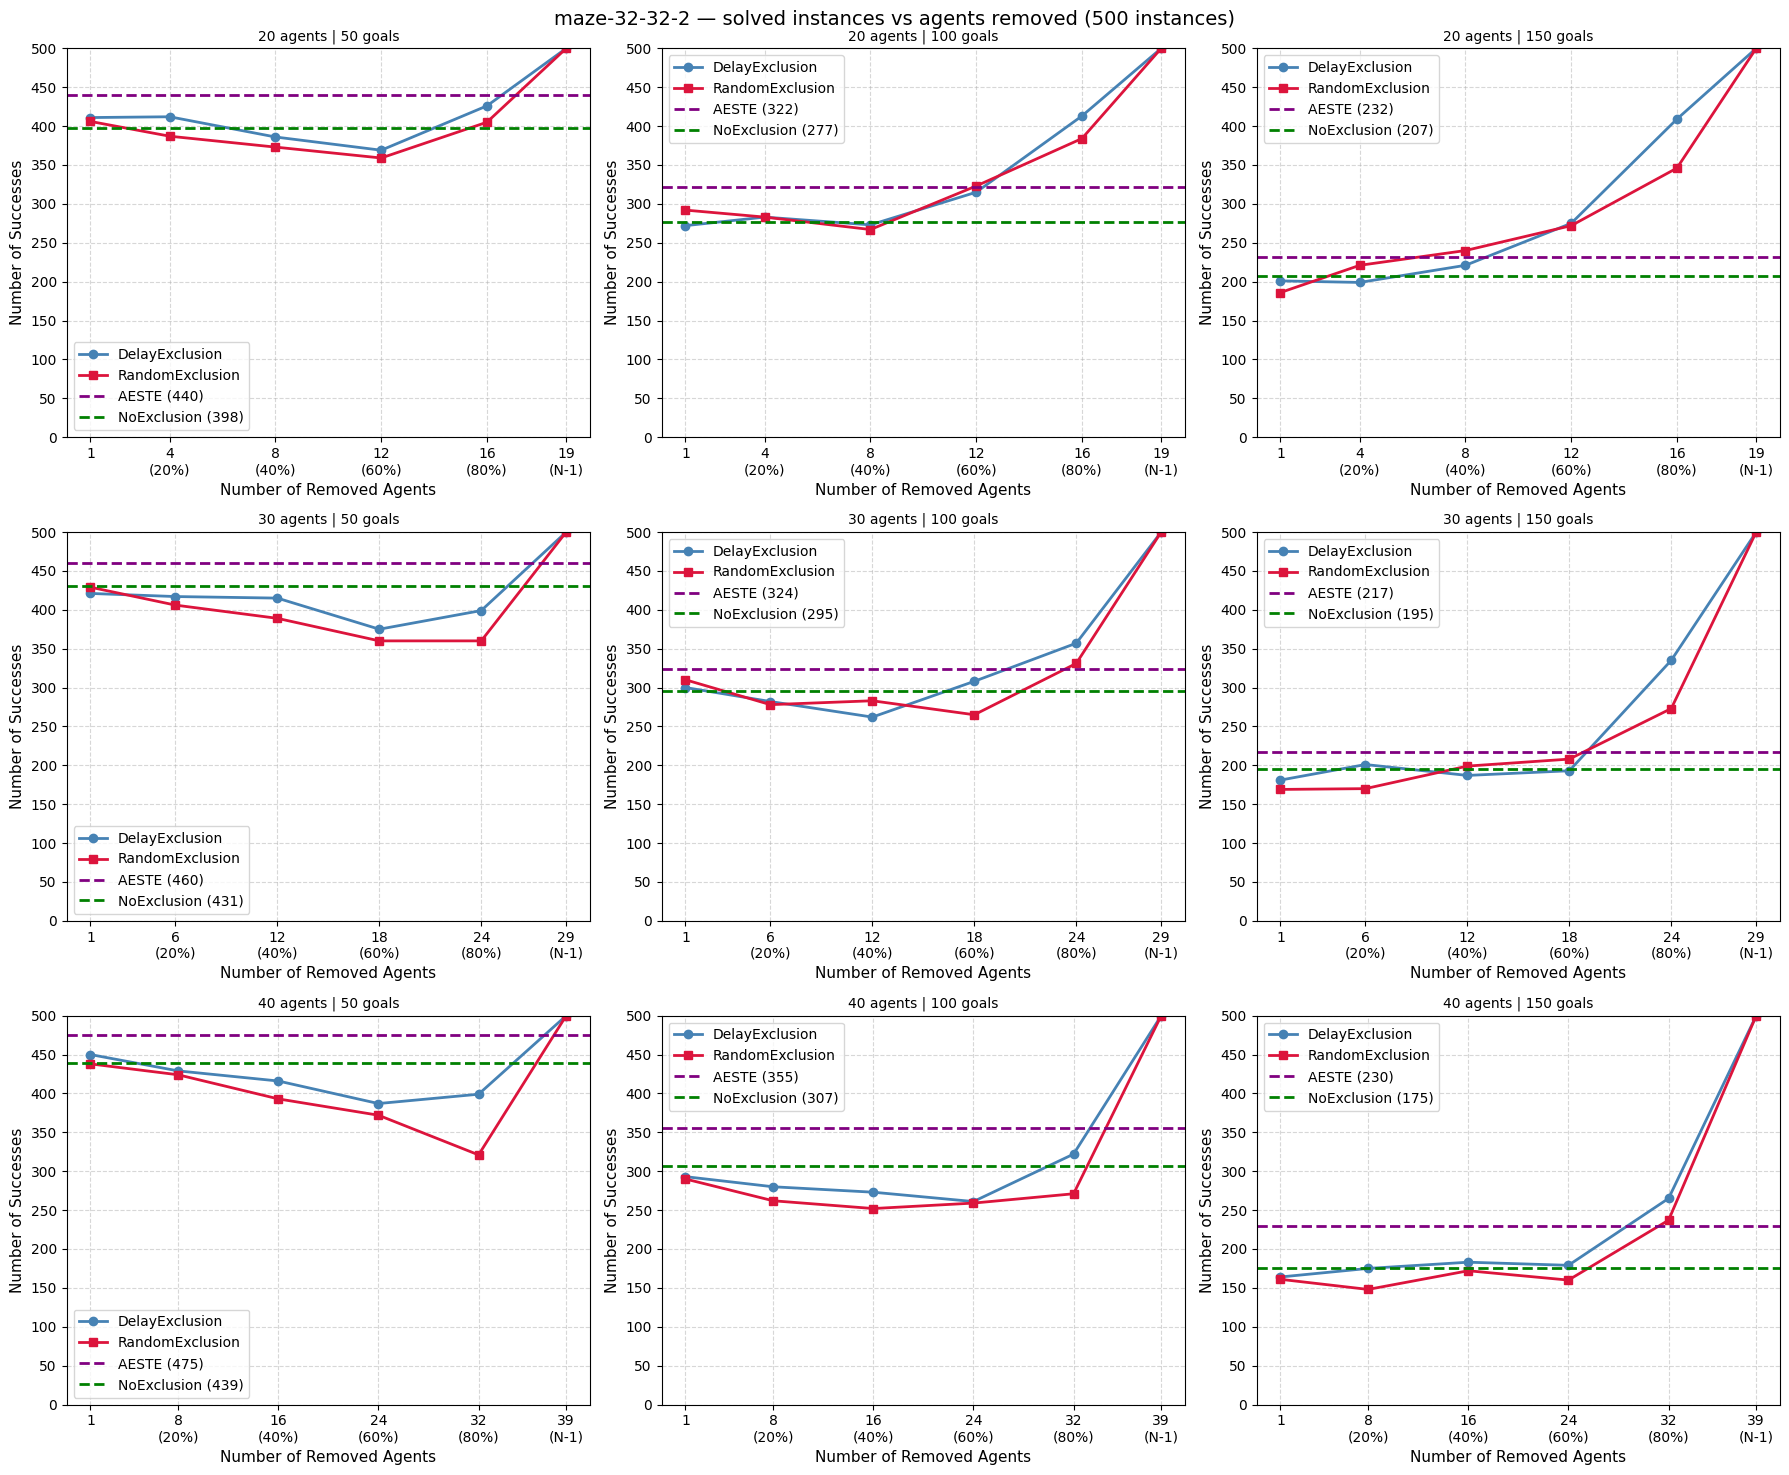

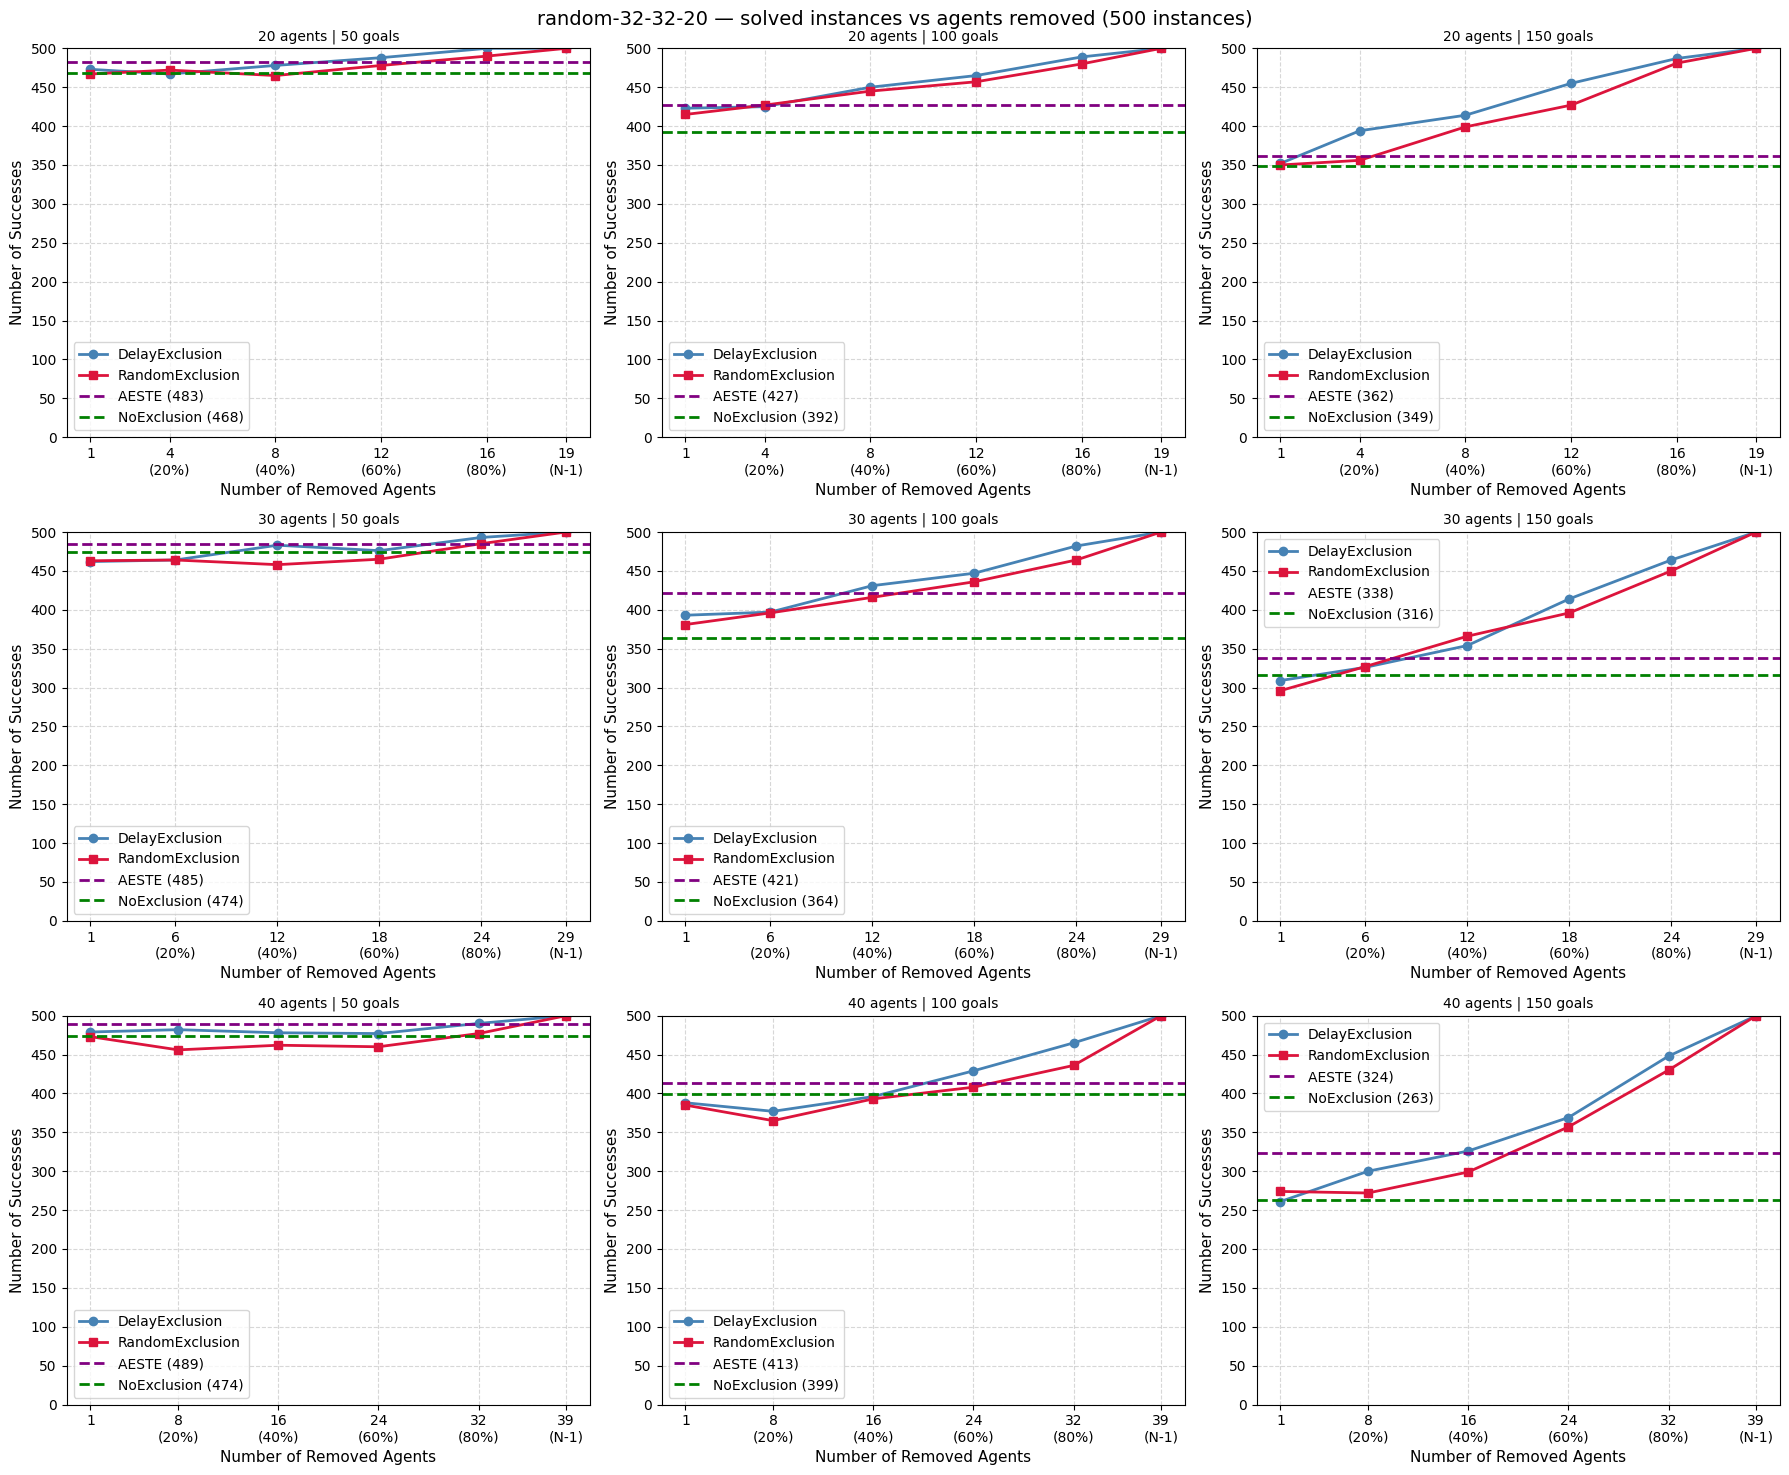

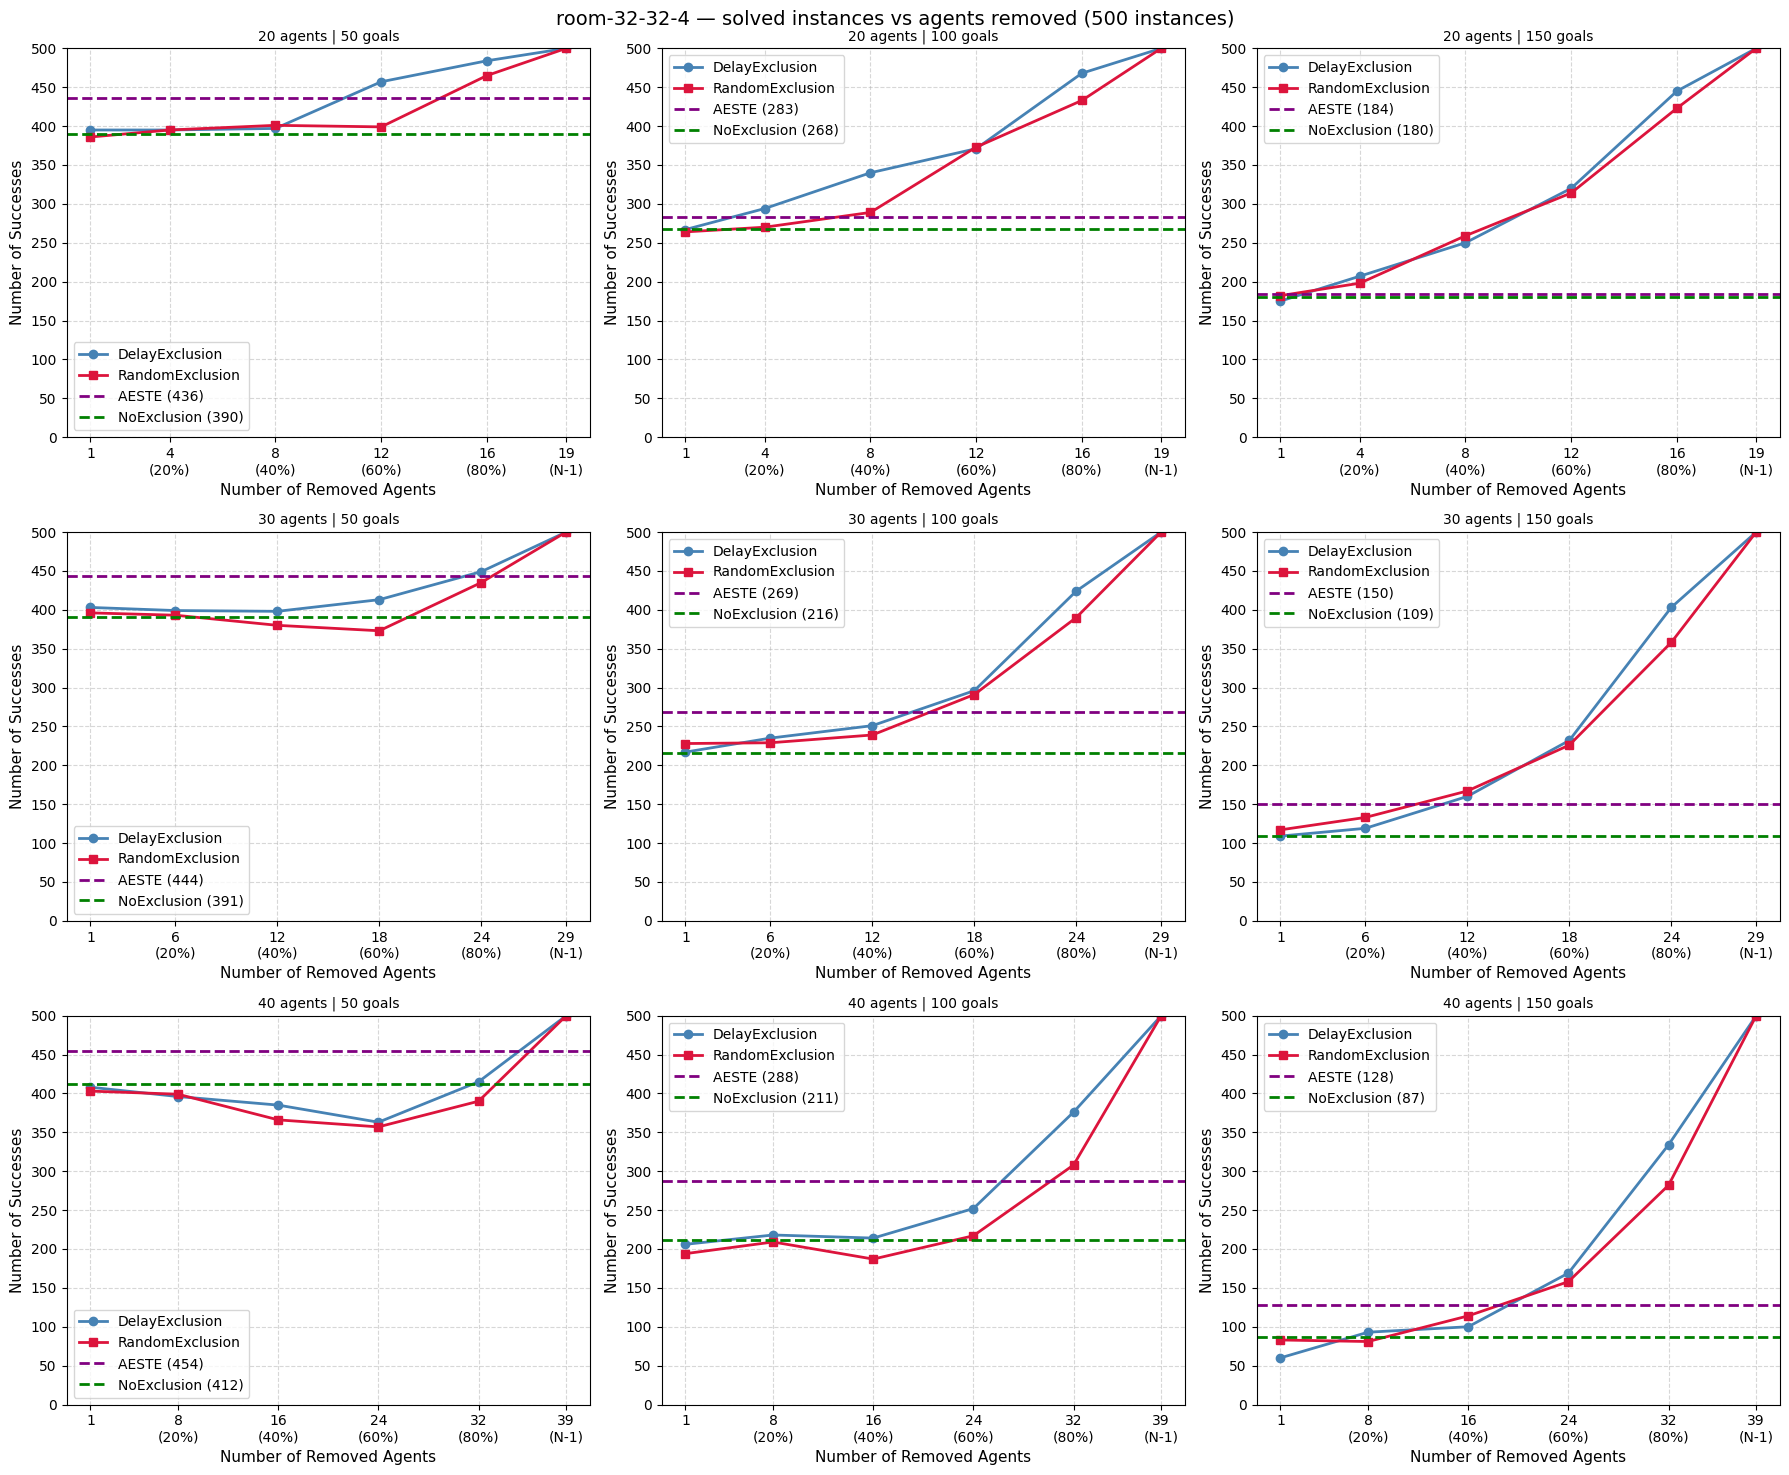

In [13]:
def plot_solved_grid(dmap, map_name):
    agent_vals, goal_vals, subs = grid_axes(dmap)
    nrows, ncols = len(agent_vals), len(goal_vals)
    n_inst = next((subs[(r, c)]["Instance"].nunique()
                   for r in range(nrows) for c in range(ncols)
                   if not subs[(r, c)].empty), 0)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    fig.suptitle(f"{map_name} — solved instances vs agents removed ({n_inst} instances)", fontsize=14)
    for r, a in enumerate(agent_vals):
        for c, g in enumerate(goal_vals):
            ax, sub = axes[r][c], subs[(r, c)]
            if sub.empty:
                ax.set_title(f"{a} agents | {g} goals\n(no data)", fontsize=10)
                ax.axis("off")
                continue
            ax.set_title(f"{a} agents | {g} goals", fontsize=10)
            plot_success_on_ax(ax, sub)
    plt.tight_layout()
    plt.show()

for m in maps:
    plot_solved_grid(df_all[df_all["Map"] == m], m)